## 
    Time period	: 1950 - 2023
    
    location:   s(glost,k=5)  
    
    scale	    1
    shape       1



In [278]:
itest='loc_loess'

In [279]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
from copy import copy

In [280]:
import rpy2
from rpy2.robjects.packages import importr, data
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
from rpy2.robjects import globalenv
pandas2ri.activate()

extRemes = importr("extRemes")
evgam = importr("evgam")
reticulate = importr("reticulate")
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [281]:
%config InlineBackend.figure_format = 'retina'
plt.style.use("cma.mplstyle")

In [282]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

# READ AFI, DJF Temperature and topography FILES

In [283]:
yearb=1950
yeare=2023

files=[f'../AFI/AFIT/AFI_ERA5_{iyear}.nc' for iyear in range(yearb,yeare+1)]

ds=xr.open_mfdataset(files)
ds=ds.sortby('lat')
ds['AFI']=ds['AFI']*5/9.
ds['time']=np.arange(yearb,yeare+1,1)

return_periods=[2, 5, 10, 25, 50, 100]
Tlon=ds.lon.data
Tlat=ds.lat.data

units='degree-days (°C)'

# Read GLOST

In [284]:
fileGLOST = '../AFI/NOAA_GLOST_anomaly.csv'
df_glost=pd.read_csv(fileGLOST,skiprows=4)
df_glost['Year']=pd.to_datetime(df_glost['Year'], format='%Y%m')
df_glost=df_glost.rename(columns={'Year': 'time'})

In [285]:
ds_glost=df_glost.set_index(['time']).to_xarray()

In [286]:
sm_x, smooth_glost = sm_lowess(ds_glost['Anomaly'], ds_glost['time'],  frac=(30*12)/len(ds_glost['time']), 
                           it=5, return_sorted = True).T
smooth_glost=xr.DataArray(smooth_glost,dims=['time'],coords={'time':ds_glost['time']})           

In [287]:
def ann_mean(var):
    month_length = var.time.dt.days_in_month
    wgts = month_length.groupby("time.year") / month_length.groupby("time.year").sum()
    var_ann = (var*wgts).groupby("time.year").sum()
    return var_ann

In [288]:
ann_glost=ann_mean(smooth_glost)
ann_glost=ann_glost.rename({'year':'time'})

In [289]:
xxx=[np.datetime64(str(ann_glost['time'].data[it])) for it in range(0,len(ann_glost['time']))]


Text(0.5, 1.0, 'GLOST timeseries')

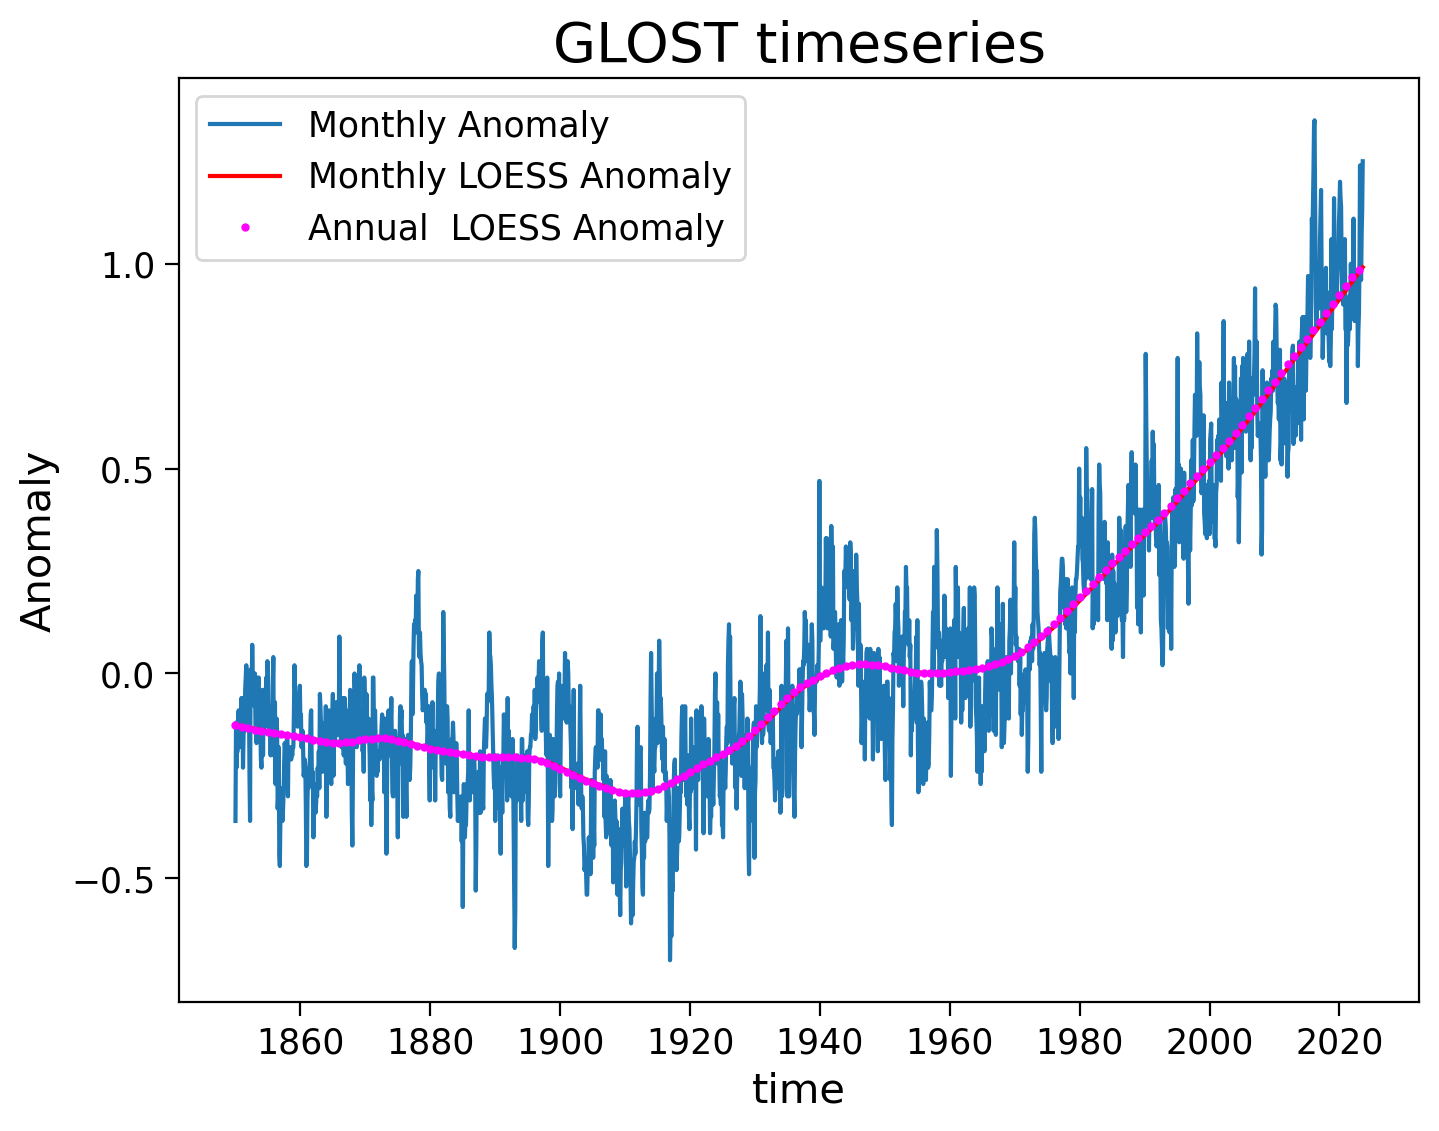

In [290]:
ds_glost['Anomaly'].plot(label='Monthly Anomaly')
plt.plot(ds_glost['time'], smooth_glost, color='red',label='Monthly LOESS Anomaly')
plt.plot(xxx, ann_glost,marker='o', linestyle='', color='magenta',markersize=2,label='Annual  LOESS Anomaly')
plt.legend()
plt.title('GLOST timeseries',fontsize=20)


In [291]:
ann_glost=ann_glost.sel(time=ds['time'])
ann_glost=ann_glost.rename({'Anomaly'})

# Merge AFI with GLOST

In [292]:
ds=ds.merge({'glost':ann_glost})

# Reduce domain for testing purpose

In [293]:
lon_min=235;lon_max=293
lat_min=28;lat_max=50

In [294]:
ds=ds.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
Tlon=ds.lon.data
Tlat=ds.lat.data

# Define EVGAM parameters for smoothness 

In [295]:
# parameters for smoothness 
%R fmla_gev <- list(AFI ~ s(glost,k=5) , ~ 1 , ~ 1)

o{'None': AFI ~ s(glost, k = 5)
, 'None': ~1
, 'None': ~1
, }

# evgam fit_gev and rl100

In [ ]:
Rlocation=xr.zeros_like(ds['AFI'].load())*np.nan
Rshape=xr.zeros_like(ds['AFI'].load())*np.nan
Rscale=xr.zeros_like(ds['AFI'].load())*np.nan
Rrl100=xr.zeros_like(ds['AFI'].load())*np.nan
NSlocpvalue=xr.zeros_like(ds['AFI'].load().mean('time'))*np.nan

mask=xr.where(np.isnan(ds['AFI'].mean('time'))==False,1,0)

idlat,idlon=np.where(mask==1)
for ij in range(0,len(idlat)):
  jj=idlat[ij]
  ii=idlon[ij]
  ilon=Tlon[ii]
  ilat=Tlat[jj]
  # Extract values for boxes
  dsij=ds.sel(lon=ilon,lat=ilat).load()
  df = dsij.to_dataframe()
  df = df.reset_index()
  # Remove zeros and NAN 
  # Remove timeseries with less than 15 data (as in Bilotta et al.)
  # Save rows removed
  dfsave=df[(df['AFI'] <= 0.)|(df['AFI'].isna())]
  df = df[df['AFI'] > 0.]

  dfsave=pd.concat([dfsave, df.groupby(['lon', 'lat']).filter(lambda x: len(x) <= 49)])
  df=df.groupby(['lon', 'lat']).filter(lambda x: len(x) > 49)
  if df.empty == True:
    Rlocation.loc[{'lat':ilat,'lon':ilon}]=-99999
    Rscale.loc[{'lat':ilat,'lon':ilon}]=-99999
    Rshape.loc[{'lat':ilat,'lon':ilon}]=-99999
    Rrl100.loc[{'lat':ilat,'lon':ilon}]=-99999
    NSlocpvalue.loc[{'lat':ilat,'lon':ilon}]=-99999
  else:  
    # Convert xarray to pandas DataFrame to R data.frame
    # You can now work with 'r_df' in R

    r_df = ro.conversion.py2rpy(df)
    globalenv['r_df'] = r_df

    # EVGAM model fitting  
    %R m_gev <- evgam(fmla_gev, r_df, family = "gev")
    %R pp <- summary(m_gev)
    %R location_pvalue <- pp[[2]][['location']][['Pr(>|t|)']]
    %R gev_pred <- predict(m_gev, r_df, type = "response")
    %R gev_rl100 <- predict(m_gev, r_df, prob = 0.99)
    %R -o gev_pred,gev_rl100,location_pvalue # get R data to python

    # Convert R data.frame to xarray
    gev_pred['time']=df['time'].values
    dsgev_pred=gev_pred.set_index(['time']).to_xarray()

    ######
    ######
    gev_rl100['time']=df['time'].values
    dsgev_rl100=gev_rl100.set_index(['time']).to_xarray()
    
    ######
    ######

    Rlocation.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}] = dsgev_pred['location'][:]
    Rscale.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}] = dsgev_pred['scale'][:]
    Rshape.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}] = dsgev_pred['shape'][:]
    Rrl100.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}] = dsgev_rl100['q:0.99'][:]
    NSlocpvalue.loc[{'lat':ilat,'lon':ilon}] = location_pvalue[0]


In [319]:
from matplotlib import cm

boxes in grey

# Read GEV parameters with scipy.stats.

In [ ]:

file0=f'../AFI/afi_return.fullUSA.gev.1980_2008_KS.nc'
ds0=xr.open_dataset(file0)
ds0=ds0.sortby('lat')
ds0=ds0.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))

Slocation = ds0['location']*5/9.
Sshape = ds0['shape']
Sscale = ds0['scale']*5/9.
Srl100 = ds0['return_afi'].sel(return_periods=100)*5/9.

The 100-year return level is expressed in degree-days (C).

In [ ]:
from copy import copy
cmap200=copy(cmaps.BlGrYeOrReVi200)
cmap200.set_under('darkgrey', 1.0)
#
cmapBR=copy(cmaps.ncl_default)
cmapBR.set_under('darkgrey', 1.0)
#
cmapBR_r=copy(cmaps.ncl_default_r)
cmapBR_r.set_under('darkgrey', 1.0)
#
proj=ccrs.PlateCarree()

# Plot location

<>:30: SyntaxWarning: invalid escape sequence '\d'
<>:32: SyntaxWarning: invalid escape sequence '\d'
<>:30: SyntaxWarning: invalid escape sequence '\d'
<>:32: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/1630122849.py:30: SyntaxWarning: invalid escape sequence '\d'
  ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/1630122849.py:32: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/1630122849.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('BuPu', len(clevs))
/var/folders/2z/v4x6xdj

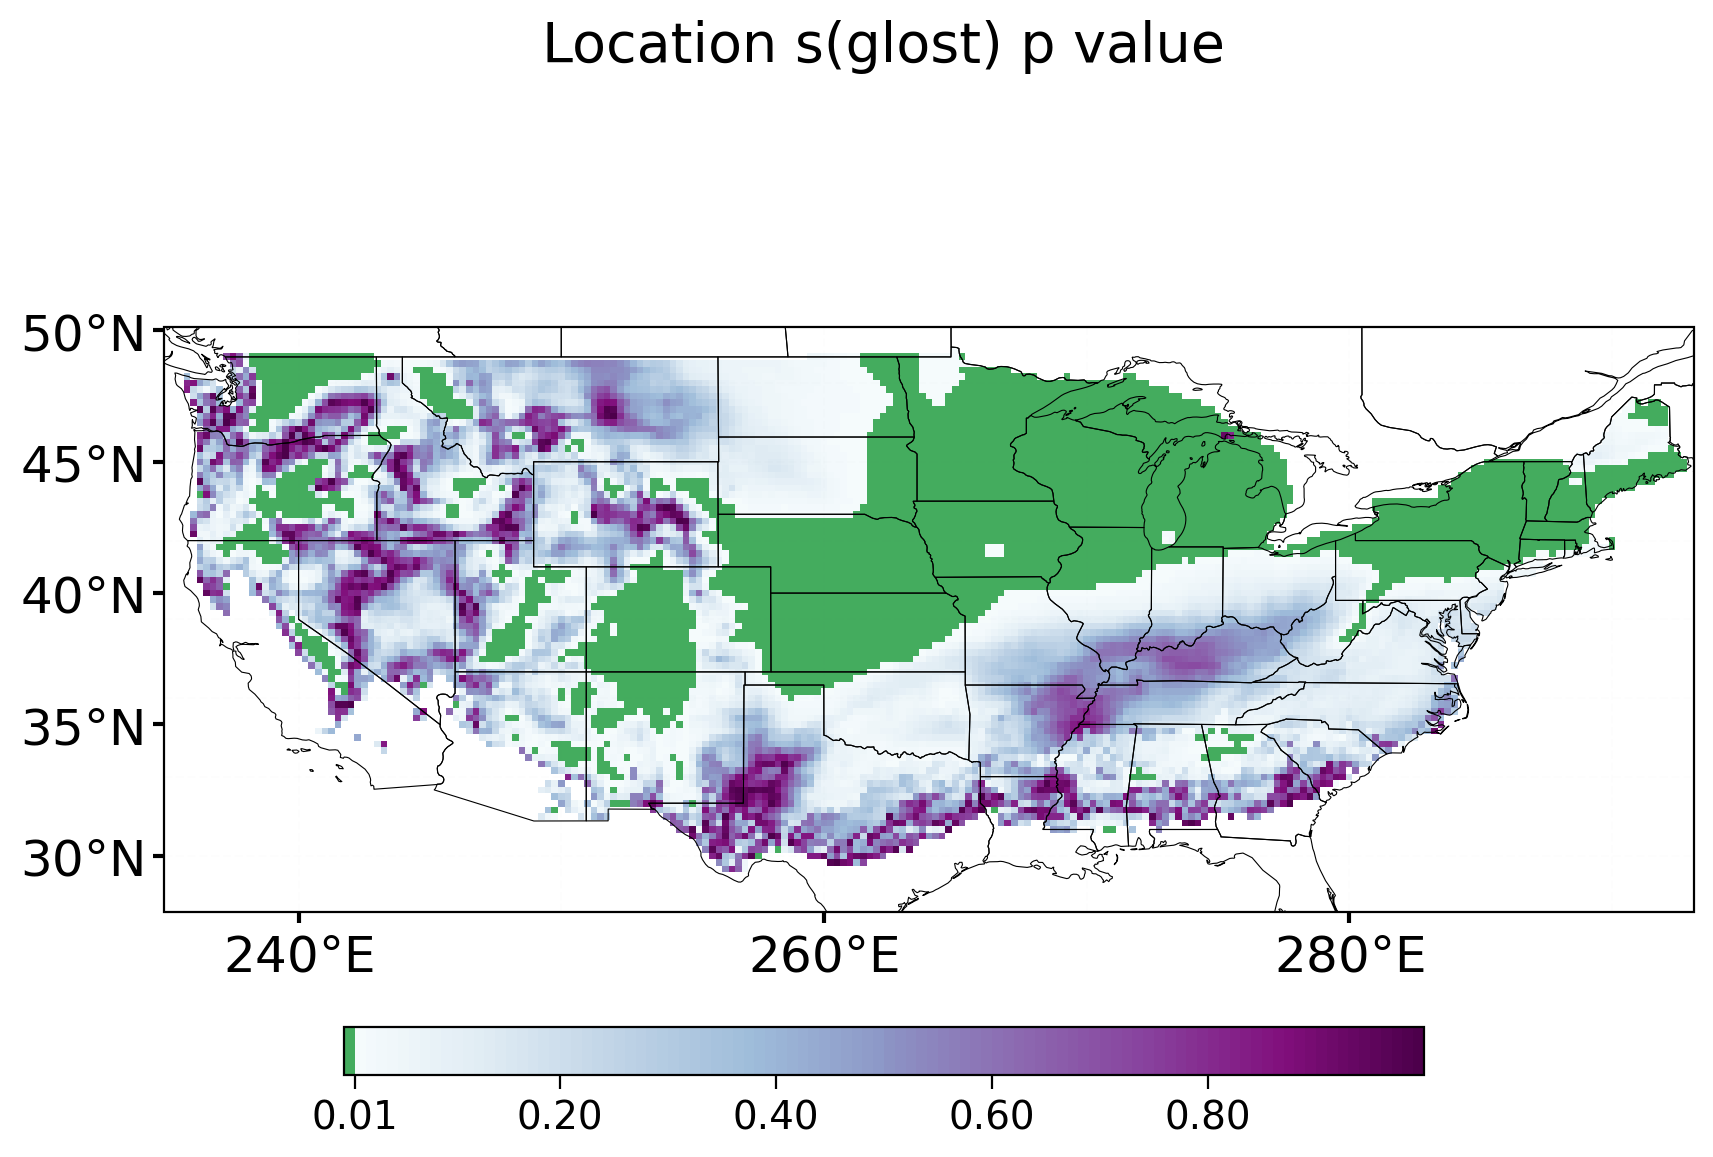

In [331]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(9,6),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.01,top=0.95, left=0.1,right=0.95,hspace=-0.05)

shrink=0.55
#
#  Location
#
clevs = np.arange(0,1.01,0.01)
cmap = cm.get_cmap('BuPu', len(clevs))
cmaplist = [cmap(i) for i in range(1,cmap.N)]
cmap2 = cm.get_cmap('Greens', 90)
cmaplist2 = [cmap2(55)]

my_cmap = colors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))


cc=NSlocpvalue.plot(ax=ax,cmap=my_cmap,levels=clevs,add_colorbar=False)
ax.set_title('',fontsize=16)
####
grd = ax.gridlines(
draw_labels=False, 
color='gray', alpha=0.01, linestyle='--')

ax.set_xlabel('')
ax.set_ylabel('')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.tick_params(axis='both',direction='out',width=1.5,length=4)
ax.set_yticks(ax.get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)
ax.set_xticks(ax.get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)
ax_cbar = fig.add_axes([0.2, 0.1, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar, ticks=[0.01,0.2,0.4,0.6,0.8],shrink=0.8,location='bottom',orientation='horizontal')
cbar.set_label(label=f'',fontsize=14)
cbar.ax.minorticks_off()
cbar.ax.tick_params(labelsize=14)

fig.suptitle('Location s(glost) p value',fontsize=20)    
outfile=f'PLOTS/GEV_NS{itest}_glost_pvalue.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

p-value for the smooth terms. green is p-value < 0.01.

<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/582749475.py:35: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/582749475.py:38: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


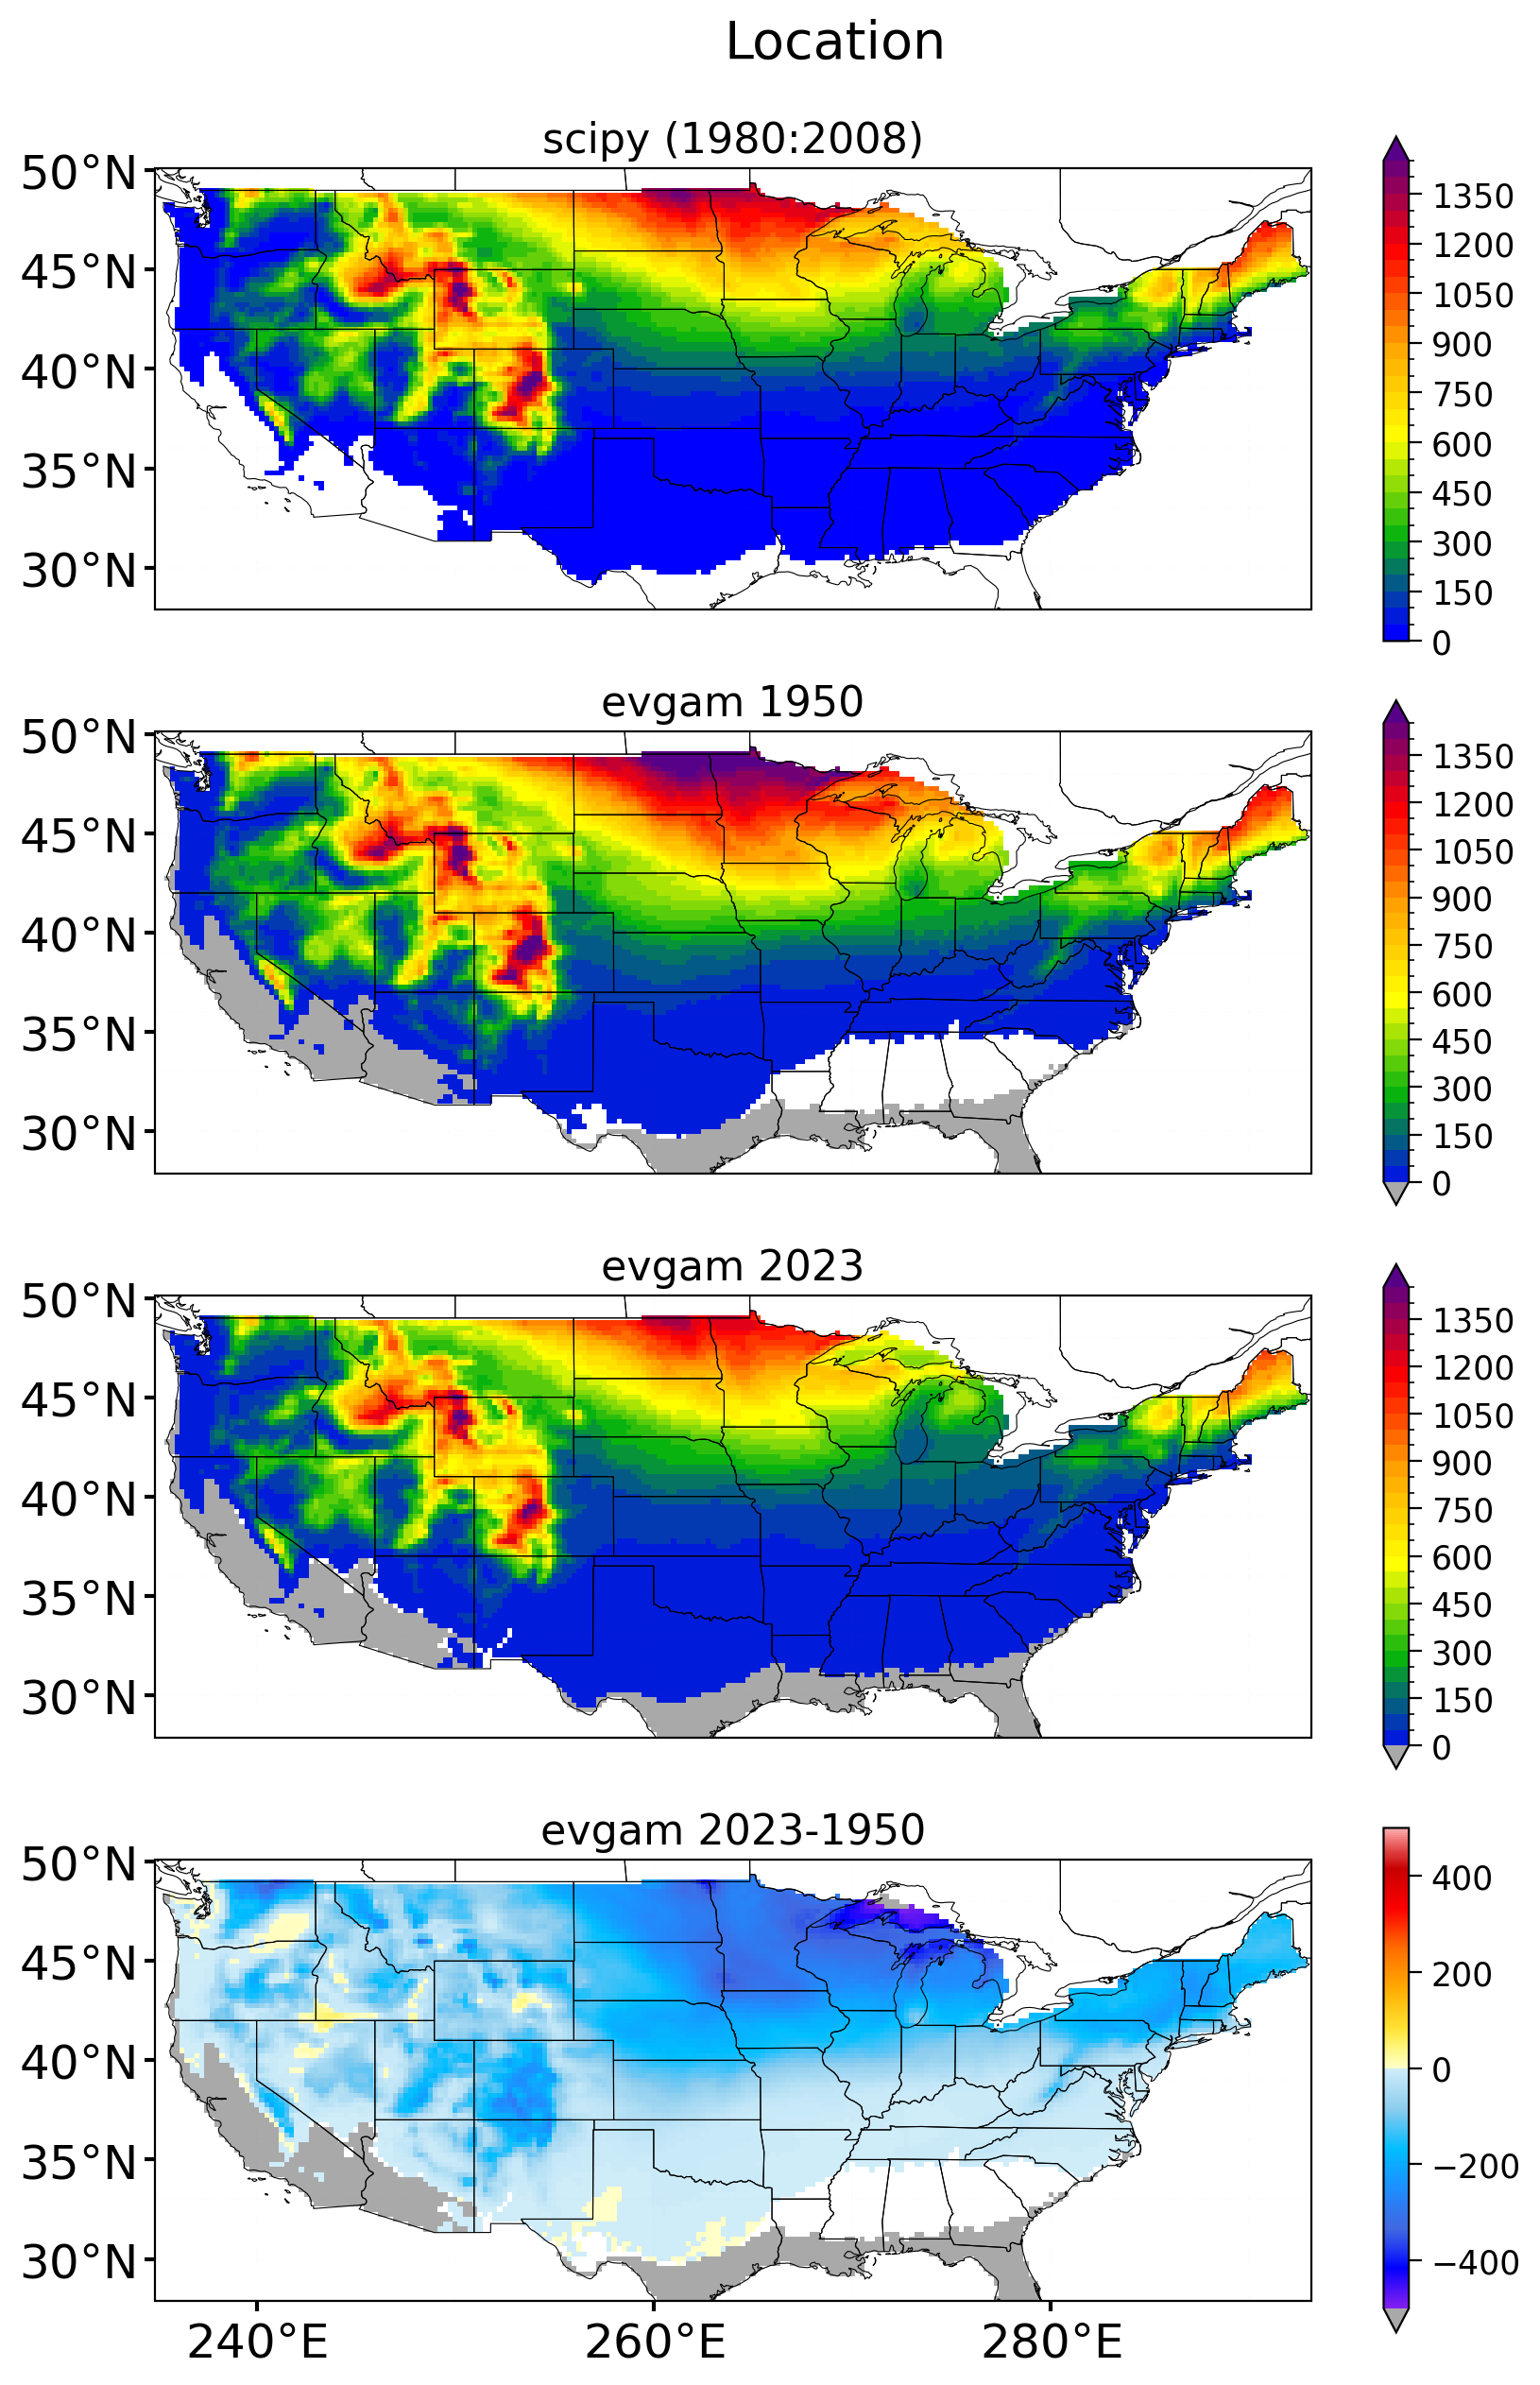

In [ ]:

fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Location
#
clevs = np.arange(0,1500,50)

Slocation.plot(ax=ax[0],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title('scipy (1980:2008)',fontsize=16)

Rlocation.isel(time=0).plot(ax=ax[1],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'evgam {yearb}',fontsize=16)

Rlocation.isel(time=73).plot(ax=ax[2],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'evgam {yeare}',fontsize=16)

data=Rlocation.isel(time=73)-Rlocation.isel(time=0)
data=xr.where(Rlocation.isel(time=0)==-999,-999,data)
data.plot(ax=ax[3],cmap=cmapBR,vmin=-500,vmax=500,cbar_kwargs={'label':'','shrink':shrink})
ax[3].set_title(f'evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')

  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Location',fontsize=20)    
outfile=f'PLOTS/GEV_NS{itest}_location.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')


In grey, not enough AFI > 0. for that point (value chosen as threshold : 49). 
In white, evgam output undefined.

# Plot Scale

<>:34: SyntaxWarning: invalid escape sequence '\d'
<>:37: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\d'
<>:37: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/4129707890.py:34: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/4129707890.py:37: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


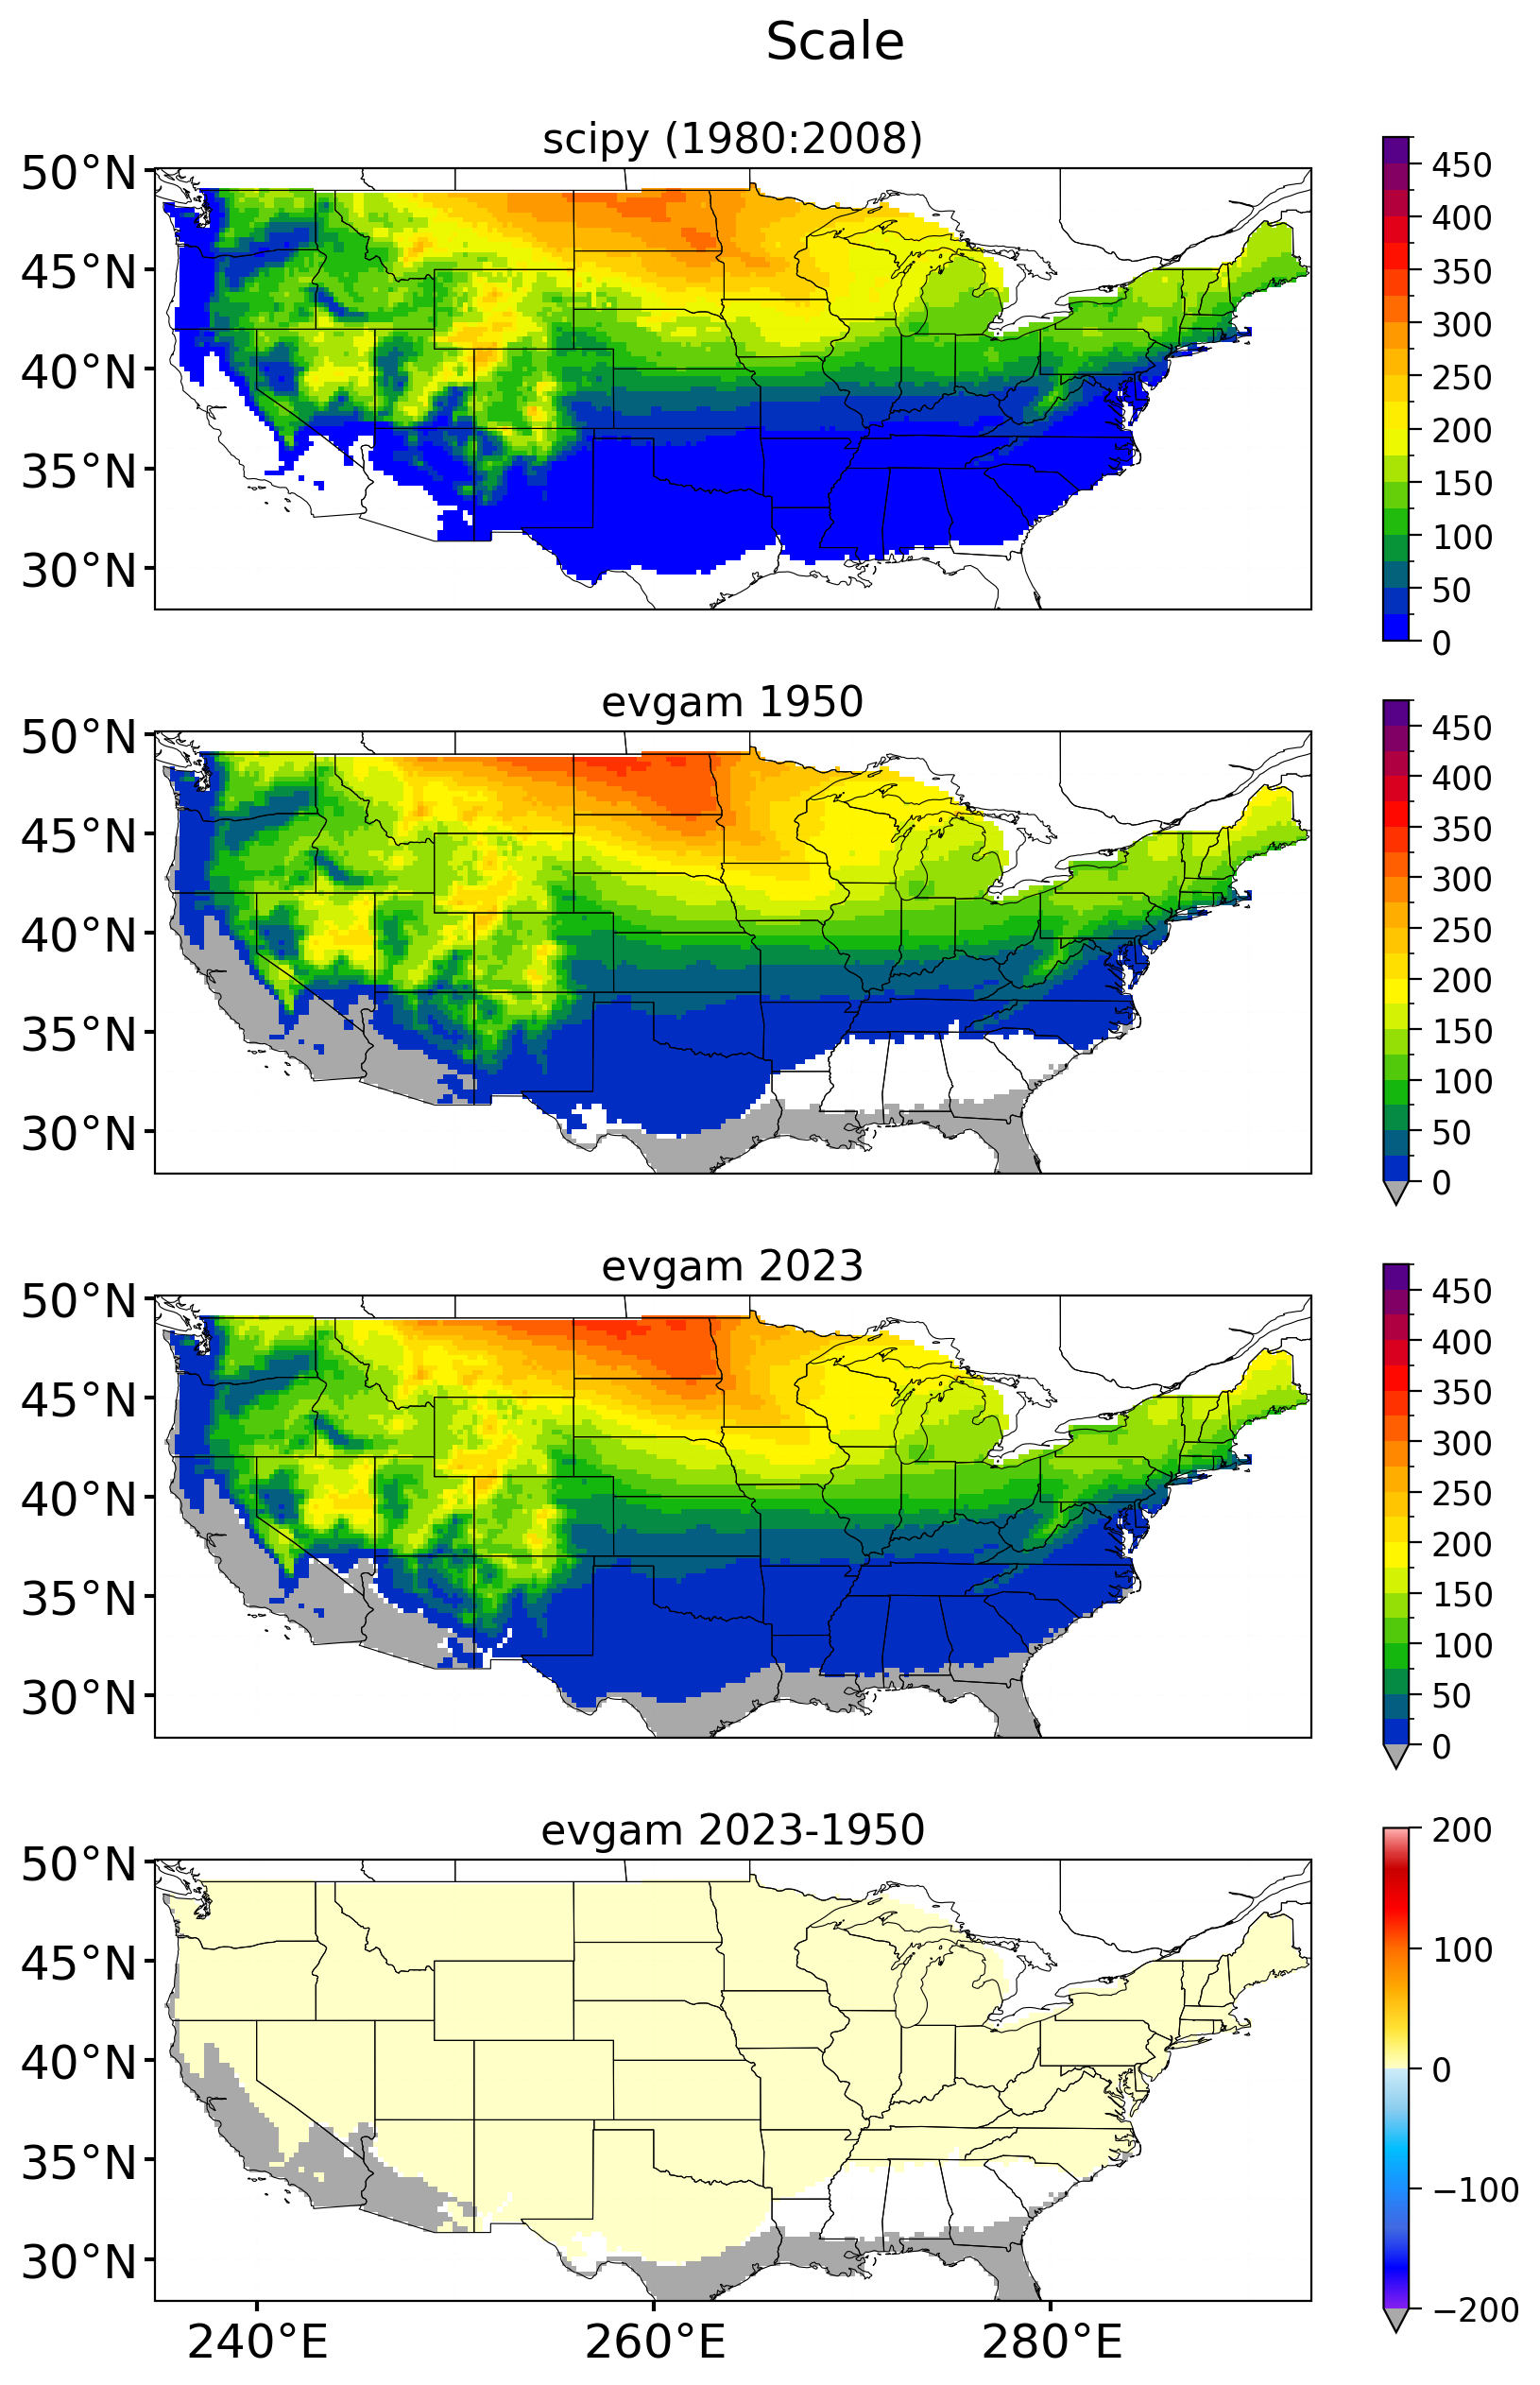

In [ ]:
fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(0,500,25)

Sscale.plot(ax=ax[0],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title('scipy (1980:2008)',fontsize=16)

Rscale.isel(time=0).plot(ax=ax[1],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'evgam {yearb}',fontsize=16)

Rscale.isel(time=73).plot(ax=ax[2],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'evgam {yeare}',fontsize=16)

data=Rscale.isel(time=73)-Rscale.isel(time=0)
data=xr.where(Rscale.isel(time=0)==-999,-999,data)
data.plot(ax=ax[3],cmap=cmapBR,vmin=-200,vmax=200,cbar_kwargs={'label':'','shrink':shrink})
ax[3].set_title(f'evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Scale',fontsize=20)    
outfile=f'PLOTS/GEV_NS{itest}_scale.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

In grey, not enough AFI > 0. for that point (value chosen as threshold : 49). 
In white, evgam output undefined.

# Plot Shape

<>:37: SyntaxWarning: invalid escape sequence '\d'
<>:40: SyntaxWarning: invalid escape sequence '\d'
<>:37: SyntaxWarning: invalid escape sequence '\d'
<>:40: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/4193660454.py:37: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/4193660454.py:40: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


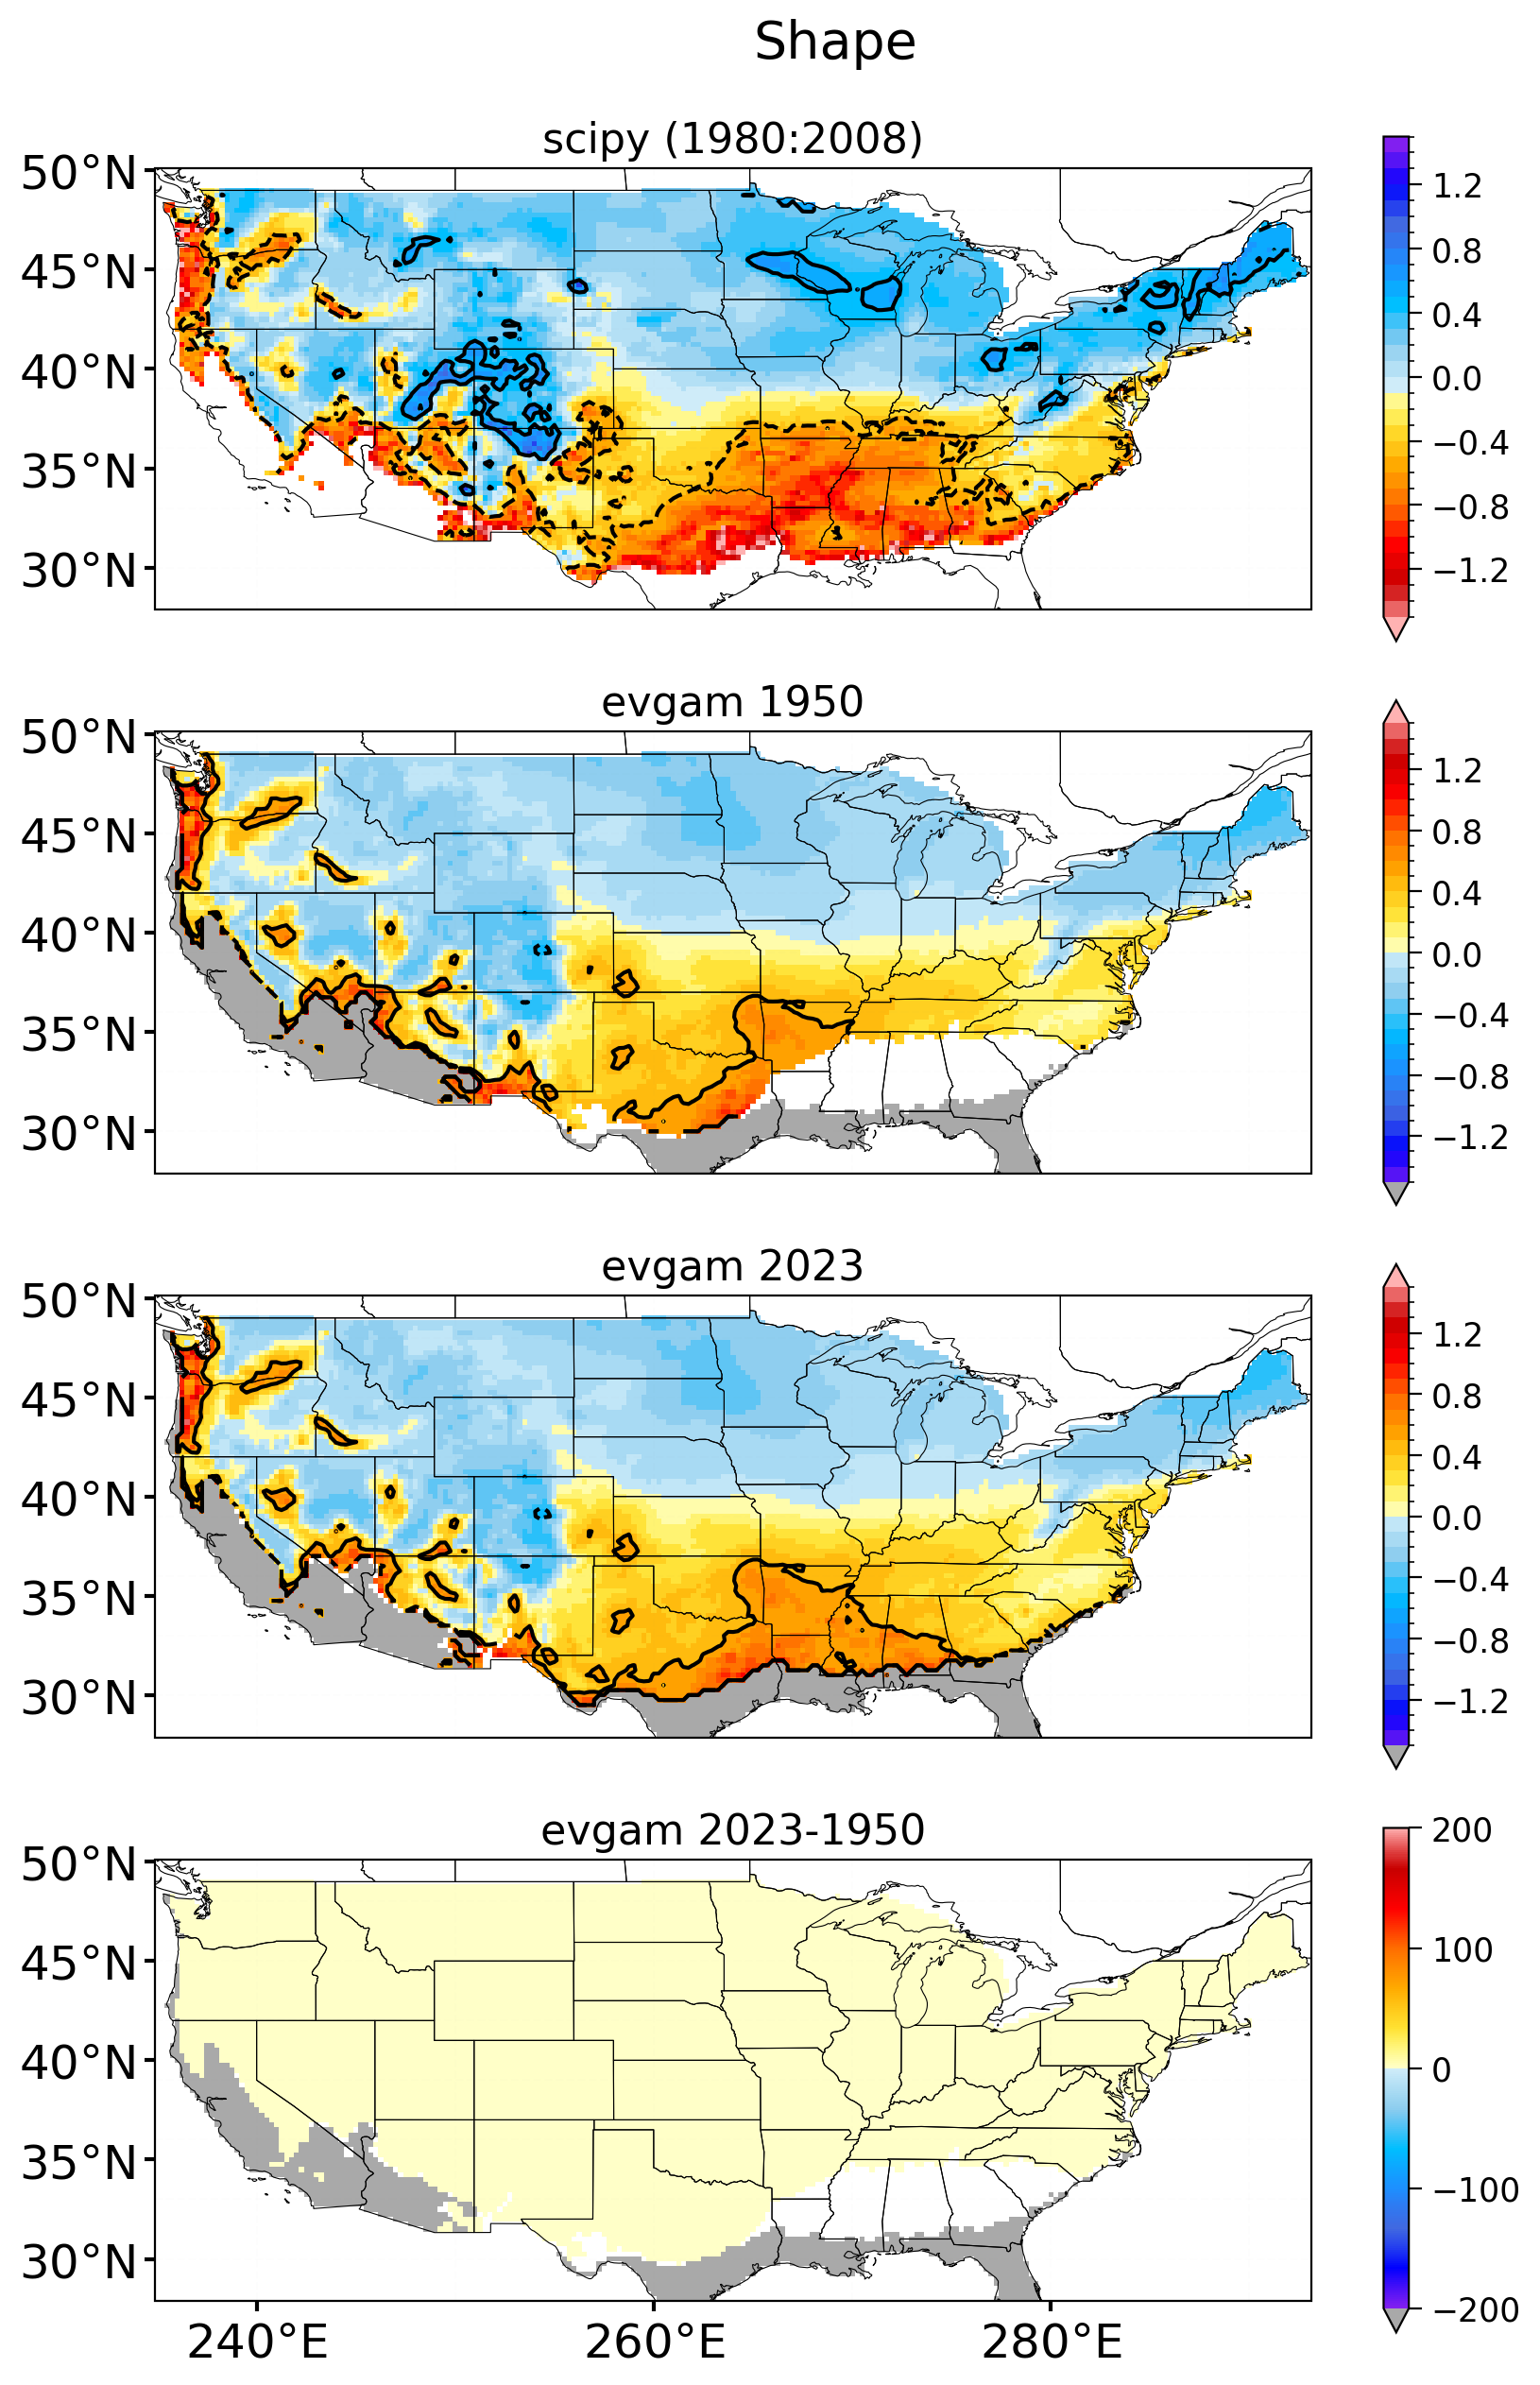

In [ ]:
fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(-1.5,1.6,0.1)

Sshape.plot(ax=ax[0],cmap=cmaps.ncl_default_r,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].contour(Sshape['lon'],Sshape['lat'],Sshape,levels=[-0.5,0.5],colors='k')
ax[0].set_title('scipy (1980:2008)',fontsize=16)

Rshape.isel(time=0).plot(ax=ax[1],cmap=cmapBR,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=0),levels=[-0.5,0.5],colors='k')
ax[1].set_title(f'evgam {yearb}',fontsize=16)

Rshape.isel(time=73).plot(ax=ax[2],cmap=cmapBR,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[2].contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=73),levels=[-0.5,0.5],colors='k')
ax[2].set_title(f'evgam {yeare}',fontsize=16)

data=Rshape.isel(time=73)-Rshape.isel(time=0)
data=xr.where(Rshape.isel(time=0)==-999,-999,data)
data.plot(ax=ax[3],cmap=cmapBR,vmin=-200,vmax=200,cbar_kwargs={'label':'','shrink':shrink})
ax[3].set_title(f'evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Shape',fontsize=20)    
outfile=f'PLOTS/GEV_NS{itest}_shape.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

In grey, not enough AFI > 0. for that point (value chosen as threshold : 49). 
In white, evgam output undefined.
The black contours are showing the shape parameters outside of [-0.5,0.5].

# Plot 100y Return Level 

<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:41: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:41: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/538901517.py:38: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/538901517.py:41: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


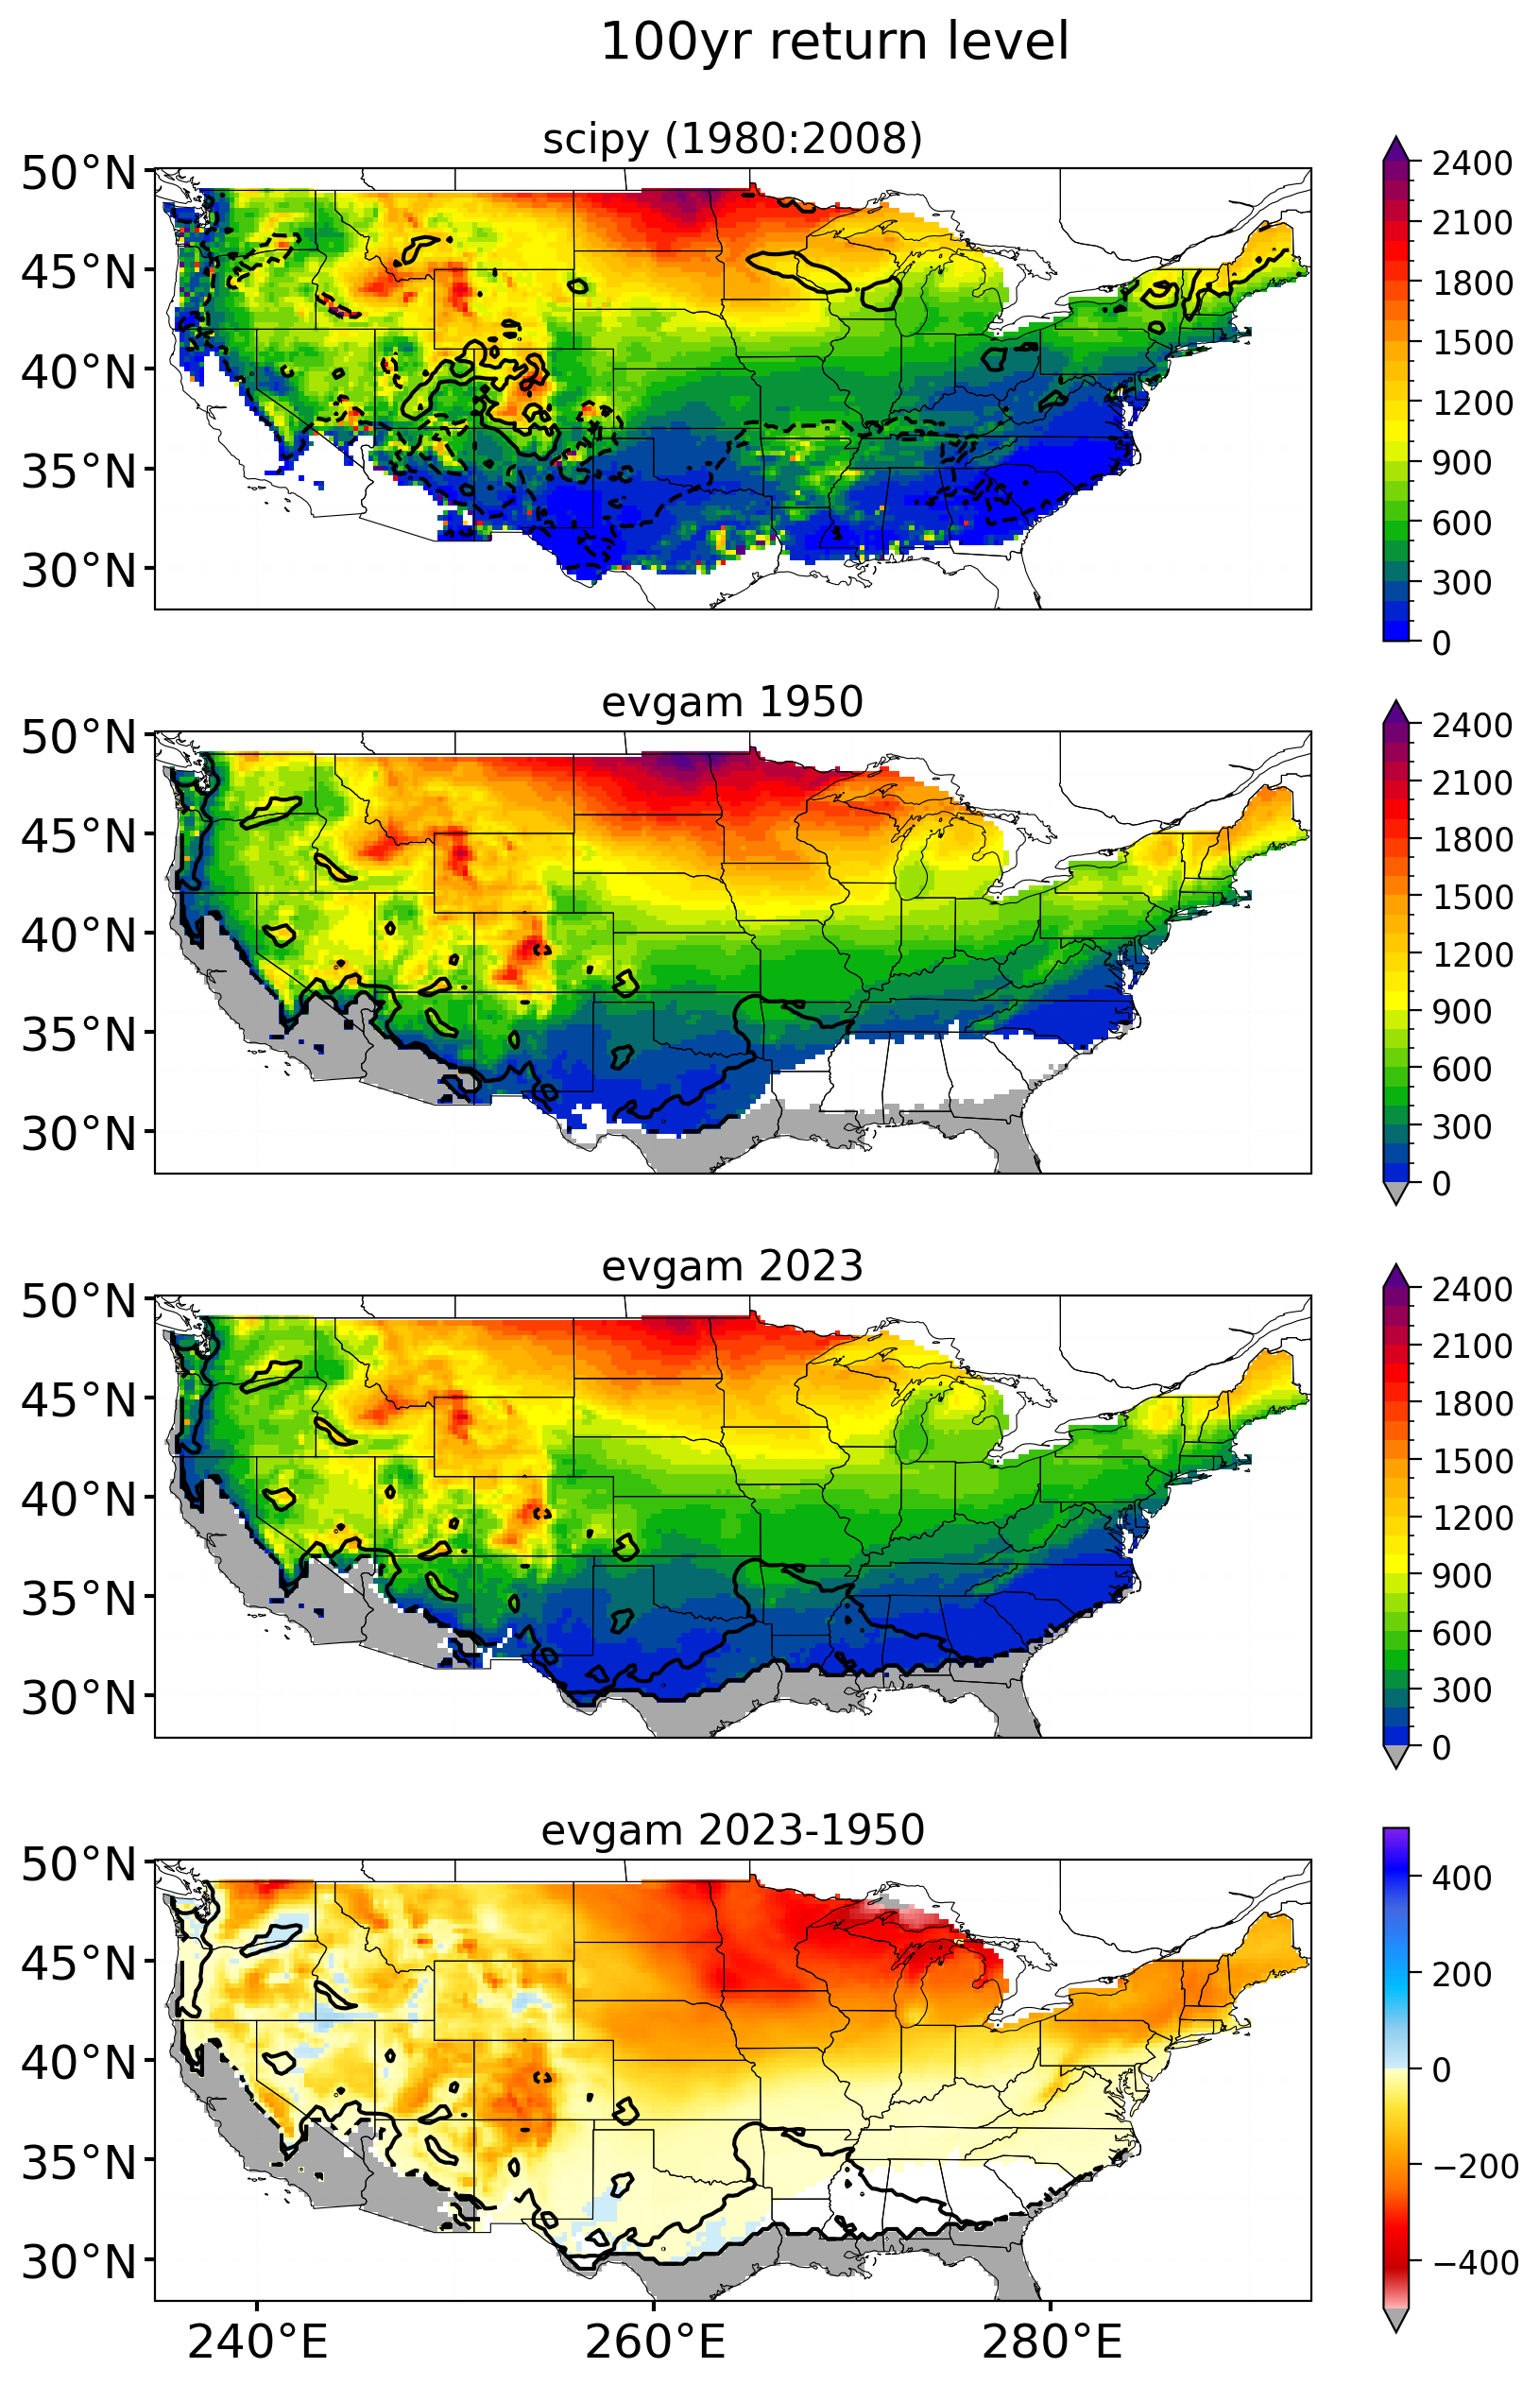

In [ ]:
fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(0,2500,100)

Srl100.plot(ax=ax[0],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].contour(Sshape['lon'],Sshape['lat'],Sshape,levels=[-0.5,0.5],colors='k')
ax[0].set_title('scipy (1980:2008)',fontsize=16)

Rrl100.isel(time=0).plot(ax=ax[1],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=0),levels=[-0.5,0.5],colors='k')
ax[1].set_title(f'evgam {yearb}',fontsize=16)

Rrl100.isel(time=73).plot(ax=ax[2],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[2].contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=73),levels=[-0.5,0.5],colors='k')
ax[2].set_title(f'evgam {yeare}',fontsize=16)

data=Rrl100.isel(time=73)-Rrl100.isel(time=0)
data=xr.where(Rrl100.isel(time=0)==-999,-999,data)
data.plot(ax=ax[3],cmap=cmapBR_r,vmin=-500,vmax=500,cbar_kwargs={'label':'','shrink':shrink})
ax[3].contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=73),levels=[-0.5,0.5],colors='k')
ax[3].set_title(f'evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('100yr return level',fontsize=20)    
outfile=f'PLOTS/GEV_NS{itest}_rl100.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

In grey, not enough AFI > 0. for that point (value chosen as threshold : 49). 
In white, evgam output undefined.
The black contours are showing the shape parameters outside of [-0.5,0.5].

# Write outfile 

In [ ]:
dsout=Rrl100.to_dataset(name='rl100')
dsout=dsout.merge({'location':Rlocation,'scale':Rscale,'shape':Rshape})
dsout.to_netcdf(f'../AFI/afi_return.evgam.{yearb}_{yeare}_{itest}.nc')

# Bilotta - Like figure 4

<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:28: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/590992898.py:25: SyntaxWarning: invalid escape sequence '\d'
  ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/590992898.py:28: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)


min: -214.34989543583174 max: 21.968038814131887


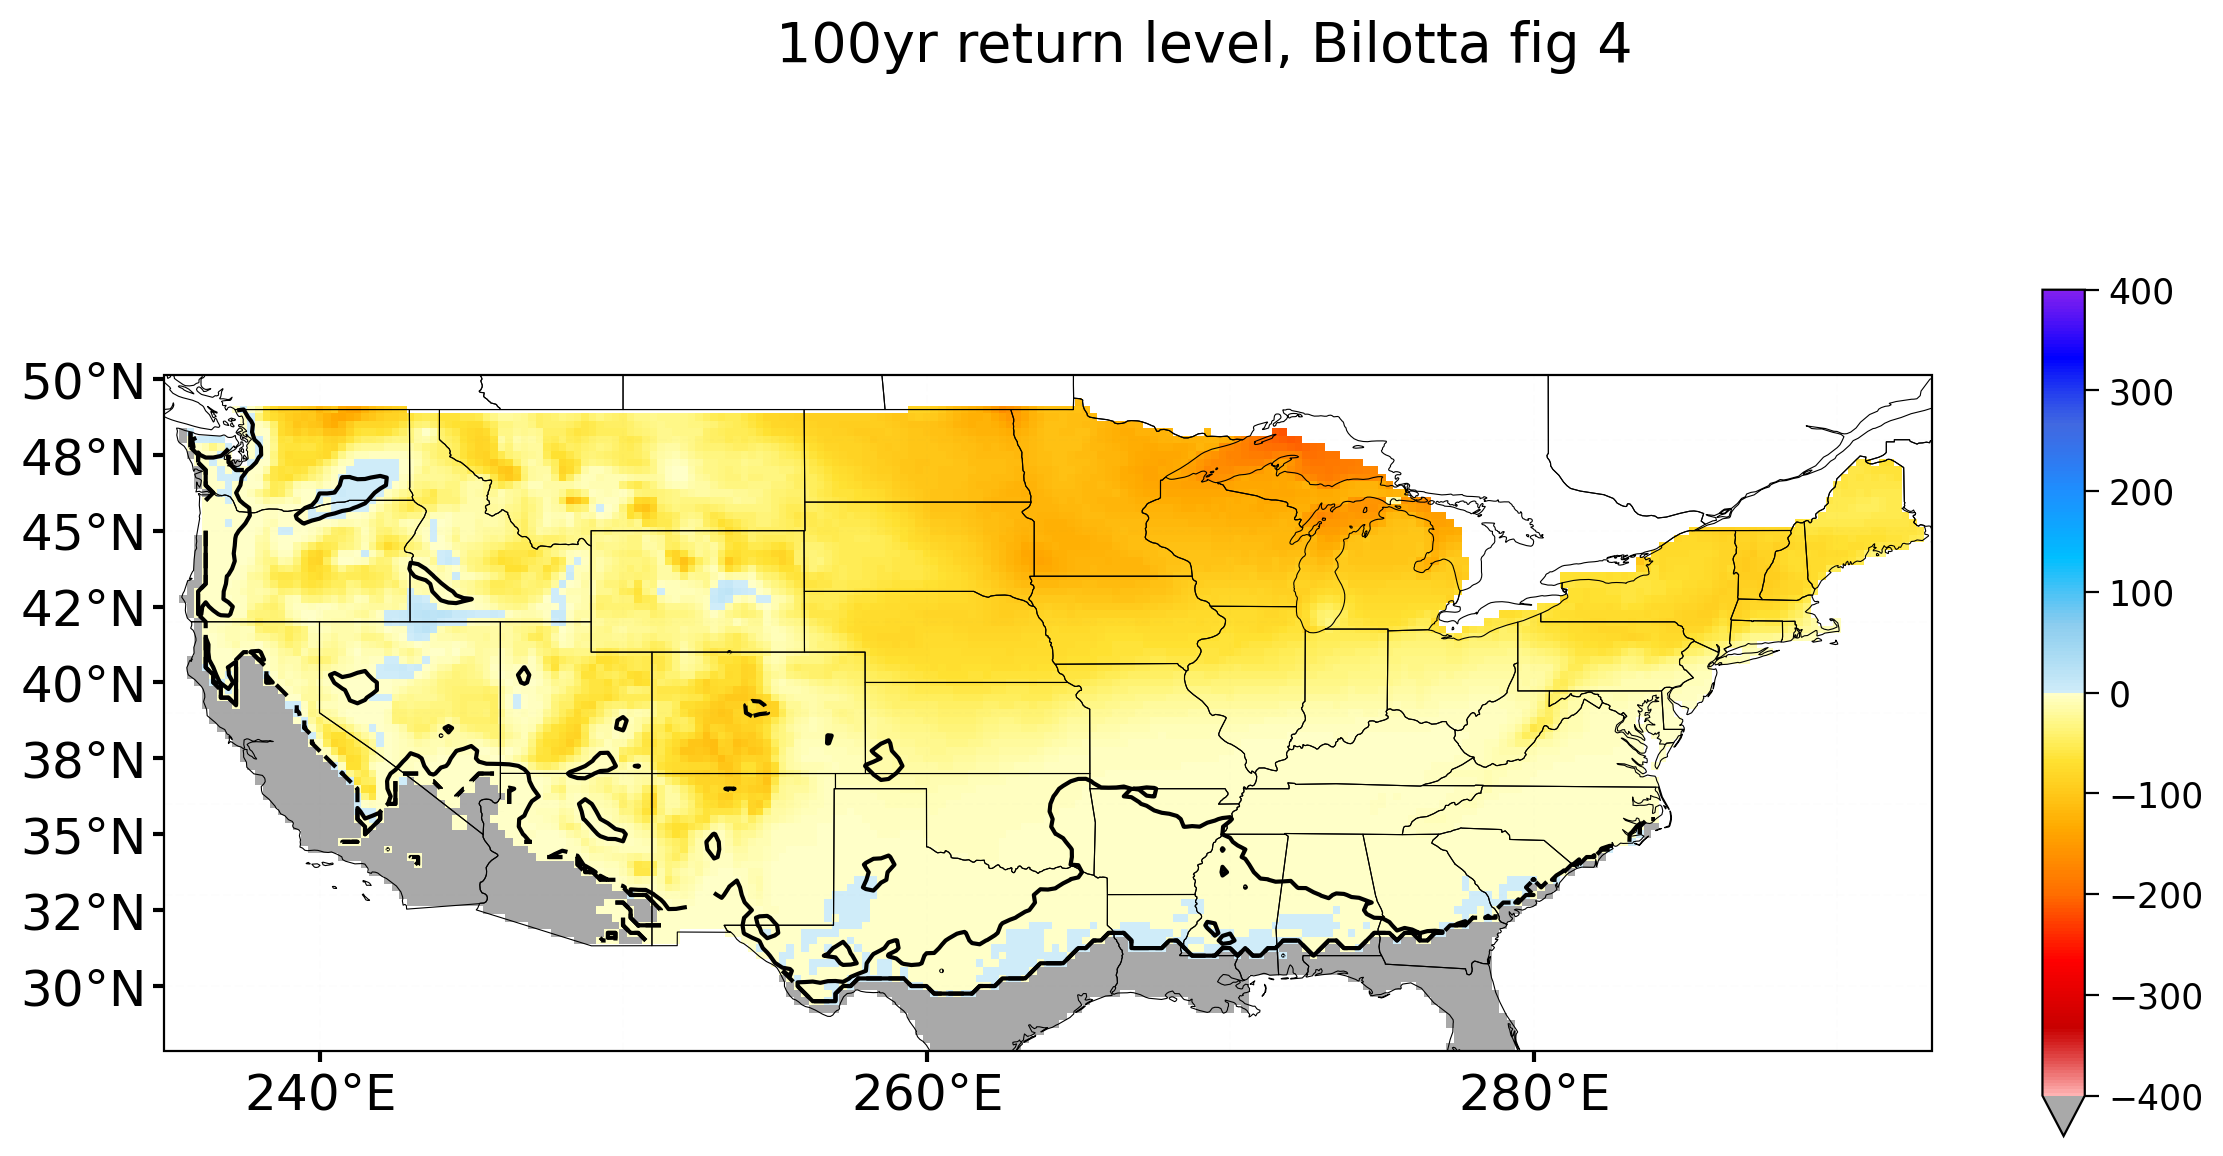

In [ ]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(13,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)

shrink=0.65
#
#  Scale
#

data1081 = Rrl100.sel(time=slice(1981,2010)).mean('time')
data8051 = Rrl100.sel(time=slice(1951,1980)).mean('time')
data = data1081 - data8051
print('min:',data.min().data,'max:',data.max().data)
data=xr.where(Rrl100.isel(time=0)==-999,-99999,data)
data.plot(ax=ax,cmap=cmapBR_r,vmin=-400,vmax=400,cbar_kwargs={'label':'','shrink':shrink})
ax.contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=73),levels=[-0.5,0.5],colors='k')

grd = ax.gridlines(
  draw_labels=False, 
  color='gray', alpha=0.01, linestyle='--')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both',direction='out',width=1.5,length=4)
ax.set_yticks(ax.get_yticks()[1:-1],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)

ax.set_xticks(ax.get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)
ax.set_title('')
fig.suptitle('100yr return level, Bilotta fig 4',fontsize=20)    
outfile=f'PLOTS/GEV_NS{itest}_figure4.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

The black contours are showing the shape parameters outside of [-0.5,0.5].

# GRID POINTS ANALYSIS

In [ ]:
ptlon=[260,264.25,241,   242,253]
ptlat=[ 48, 37.  , 46.25, 40, 38]

<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/1107244967.py:19: SyntaxWarning: invalid escape sequence '\d'
  ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_12104/1107244967.py:22: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)


Text(0.5, 1.0, '100yr return level,2023-1950')

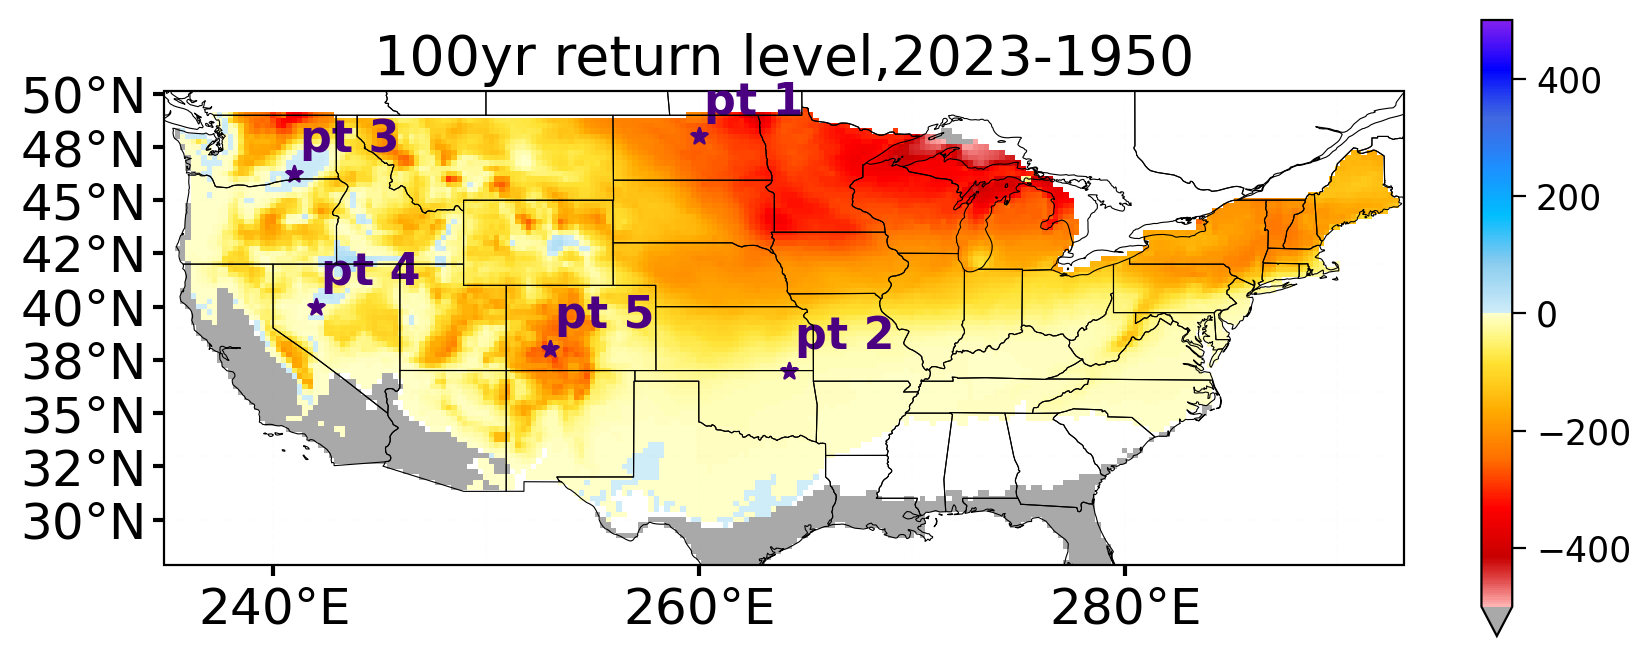

In [ ]:
cmap=cmaps.BlGrYeOrReVi200

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,8),subplot_kw={'projection':proj})
data=Rrl100.isel(time=73)-Rrl100.isel(time=0)
data=xr.where(Rrl100.isel(time=0)==-999,-999,data)
data.plot(cmap=cmapBR_r,vmin=-500,vmax=500,cbar_kwargs={'label':'','shrink':0.5})
for ip in range(0,len(ptlon)):
  ax.scatter(ptlon[ip],ptlat[ip],marker='*',color='indigo')
  ax.text(ptlon[ip]-360+0.25,ptlat[ip]+1,f'pt {ip+1}',color='indigo',size=16,weight='bold')

grd = ax.gridlines(
  draw_labels=False, 
  color='gray', alpha=0.01, linestyle='--')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both',direction='out',width=1.5,length=4)
ax.set_yticks(ax.get_yticks()[1:-1],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)

ax.set_xticks(ax.get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)
ax.set_title(f'100yr return level,{yeare}-{yearb}',fontsize=20)

<>:45: SyntaxWarning: invalid escape sequence '\d'
<>:45: SyntaxWarning: invalid escape sequence '\d'
<>:59: SyntaxWarning: invalid escape sequence '\d'
<>:59: SyntaxWarning: invalid escape sequence '\d'
<>:67: SyntaxWarning: invalid escape sequence '\d'
<>:71: SyntaxWarning: invalid escape sequence '\d'
<>:71: SyntaxWarning: invalid escape sequence '\d'
<>:79: SyntaxWarning: invalid escape sequence '\d'
<>:83: SyntaxWarning: invalid escape sequence '\d'
<>:83: SyntaxWarning: invalid escape sequence '\d'
<>:45: SyntaxWarning: invalid escape sequence '\d'
<>:45: SyntaxWarning: invalid escape sequence '\d'
<>:59: SyntaxWarning: invalid escape sequence '\d'
<>:59: SyntaxWarning: invalid escape sequence '\d'
<>:67: SyntaxWarning: invalid escape sequence '\d'
<>:71: SyntaxWarning: invalid escape sequence '\d'
<>:71: SyntaxWarning: invalid escape sequence '\d'
<>:79: SyntaxWarning: invalid escape sequence '\d'
<>:83: SyntaxWarning: invalid escape sequence '\d'
<>:83: SyntaxWarning: invalid e

#############
#############
Point 1
#############
#############


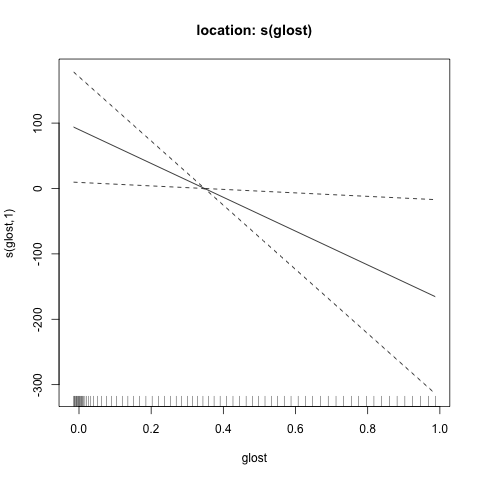


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  1245.87      42.16   29.55   <2e-16

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     5.77        0.1   58.75   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     -0.3        0.1   -3.07  0.00107

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4   4.97   0.0258
#############
#############
Point 2
#############
#############


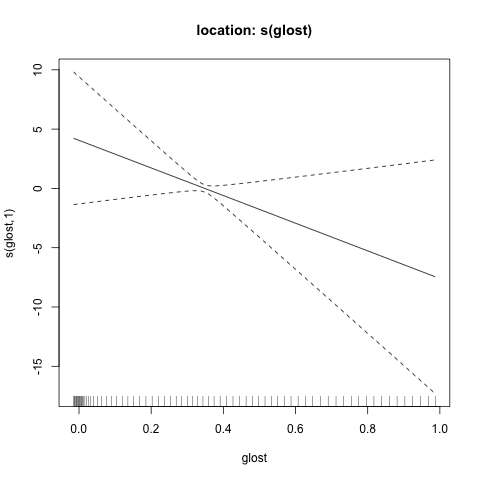


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    42.41       3.99   10.64   <2e-16

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     3.35       0.12      27   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     0.39       0.13    2.94  0.00162

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4   2.29     0.13
#############
#############
Point 3
#############
#############


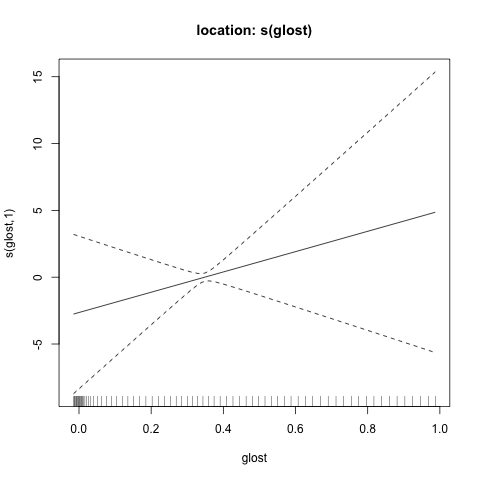


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    36.79       4.95    7.44 5.05e-14

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     3.56       0.14   25.36   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     0.58       0.15    3.92 4.42e-05

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4   0.86    0.355
#############
#############
Point 4
#############
#############


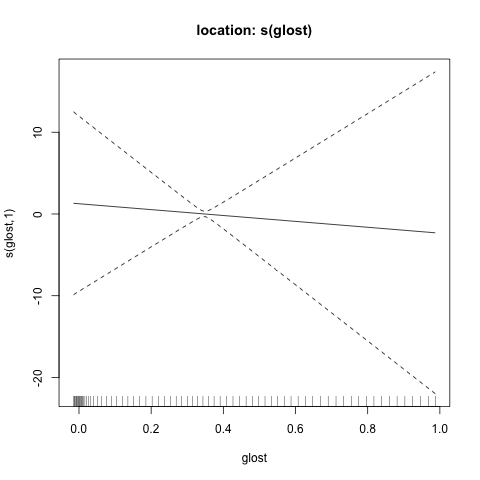


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    68.58       8.69    7.89 1.49e-15

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     4.09       0.13   30.78   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     0.44       0.15    2.91  0.00181

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4   0.05    0.815
#############
#############
Point 5
#############
#############


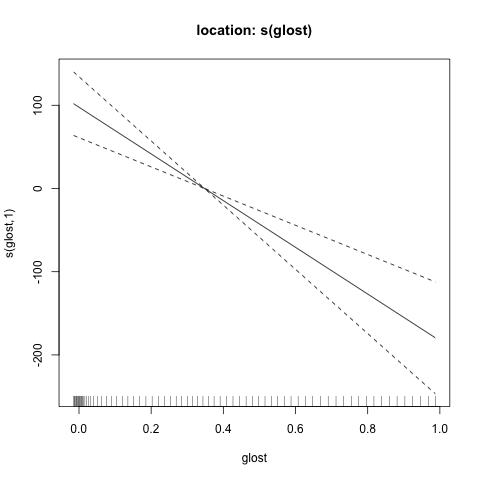


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  1336.24      17.59   75.97   <2e-16

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     4.94       0.09   57.35   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    -0.18       0.06   -3.11 0.000951

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4  28.52 9.27e-08


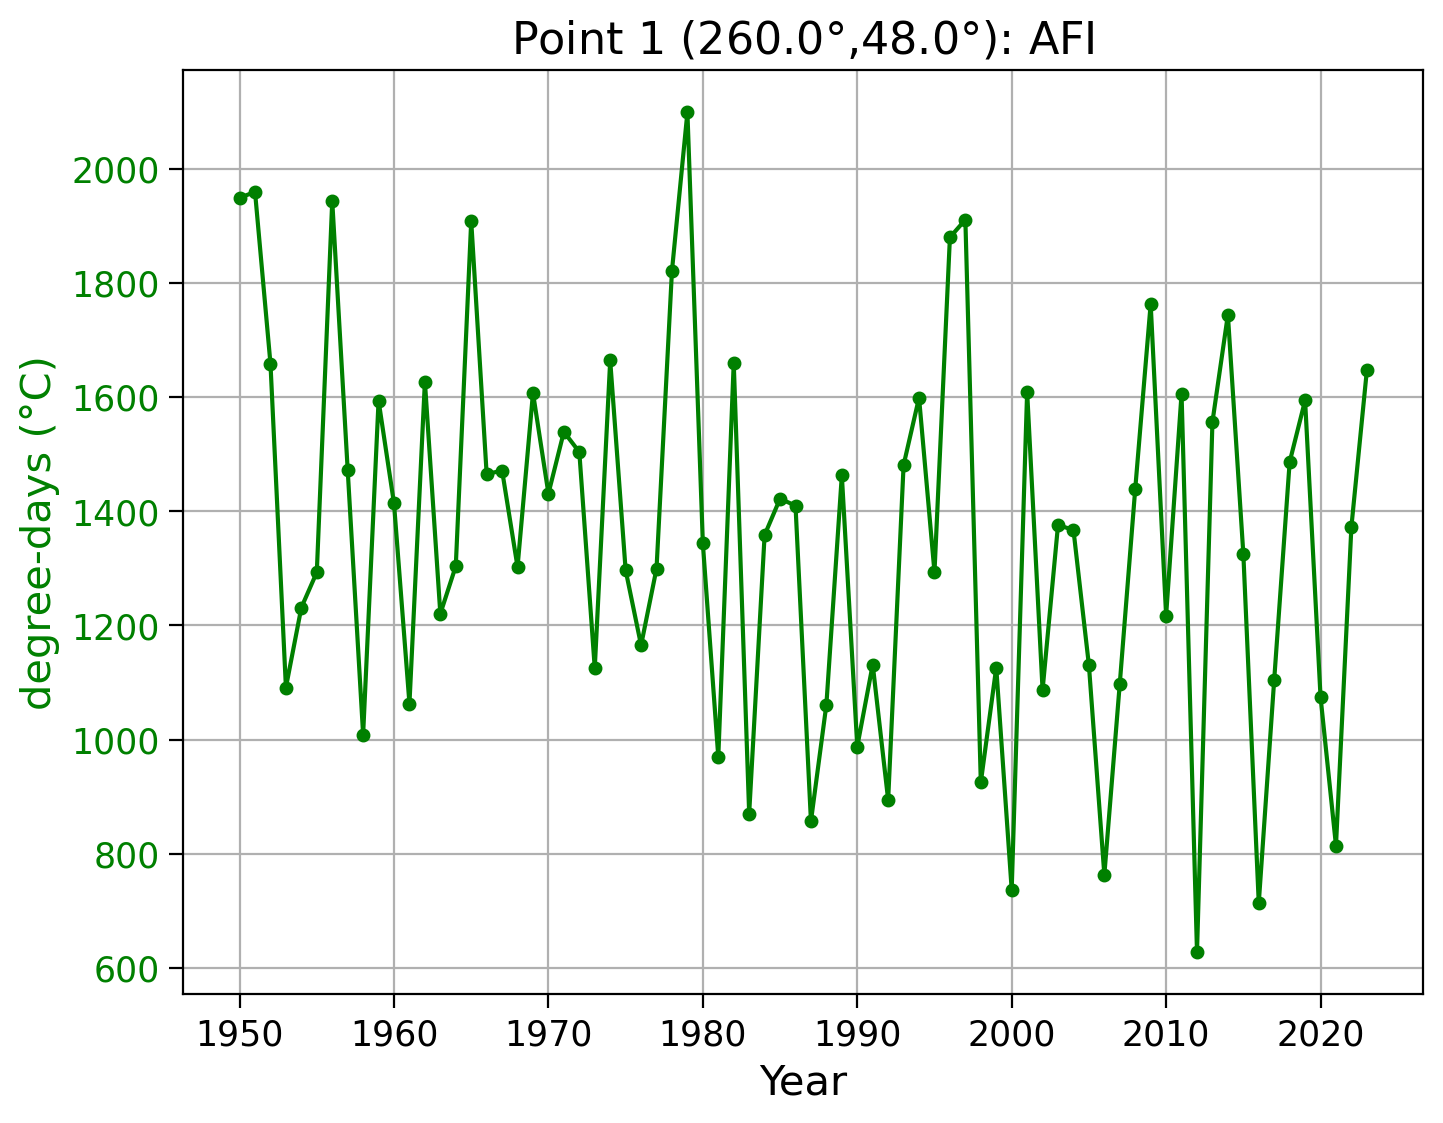

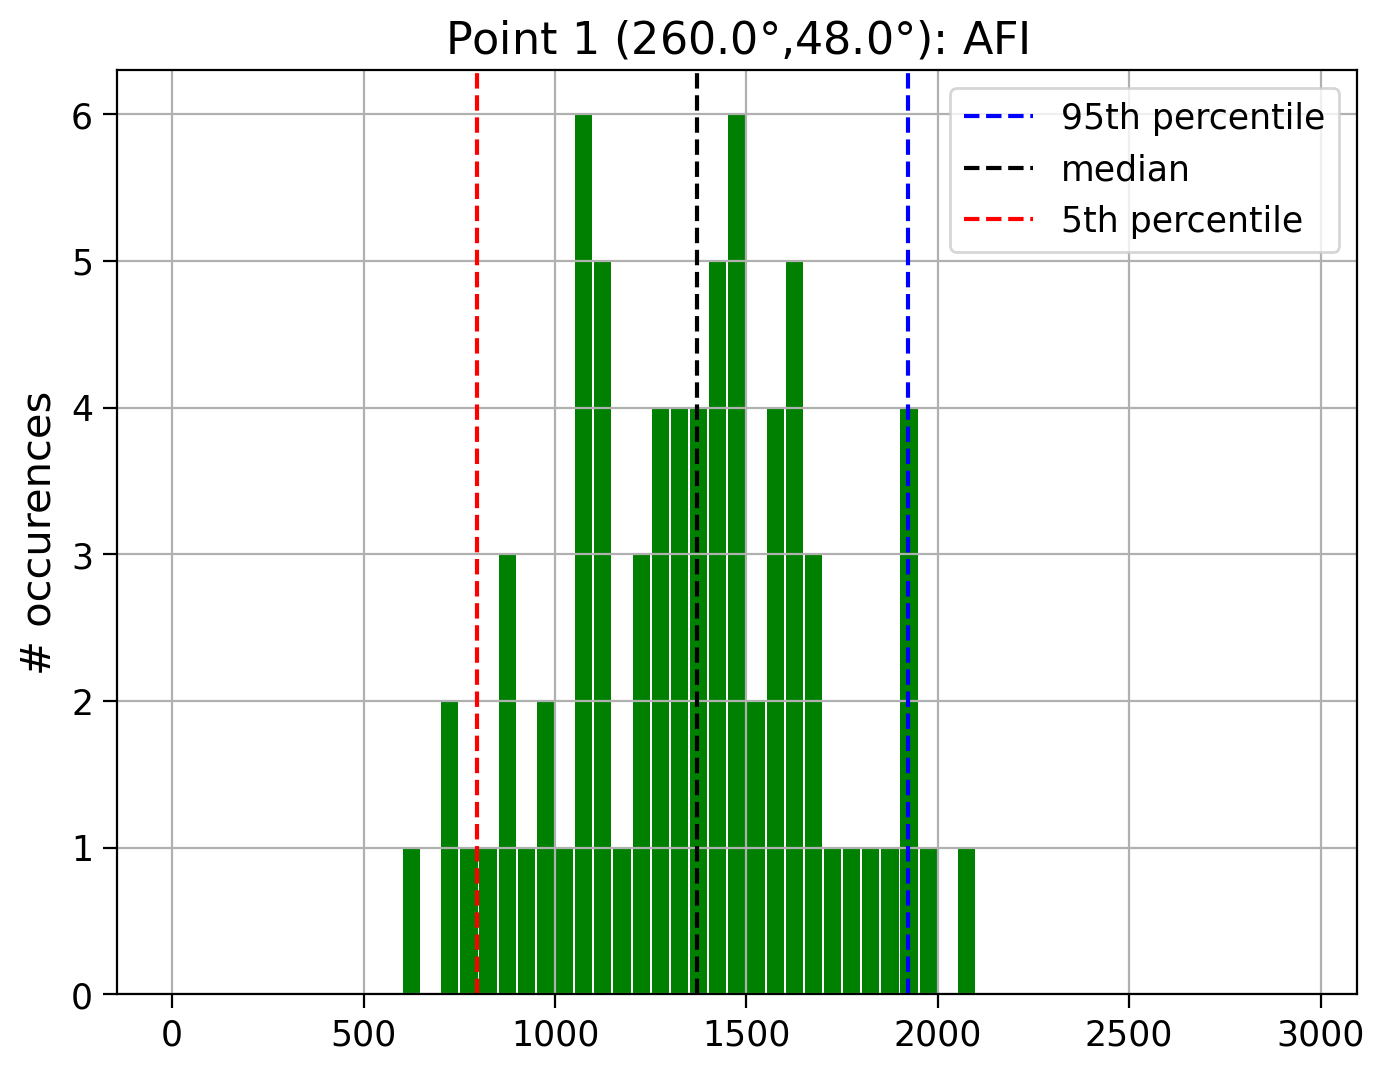

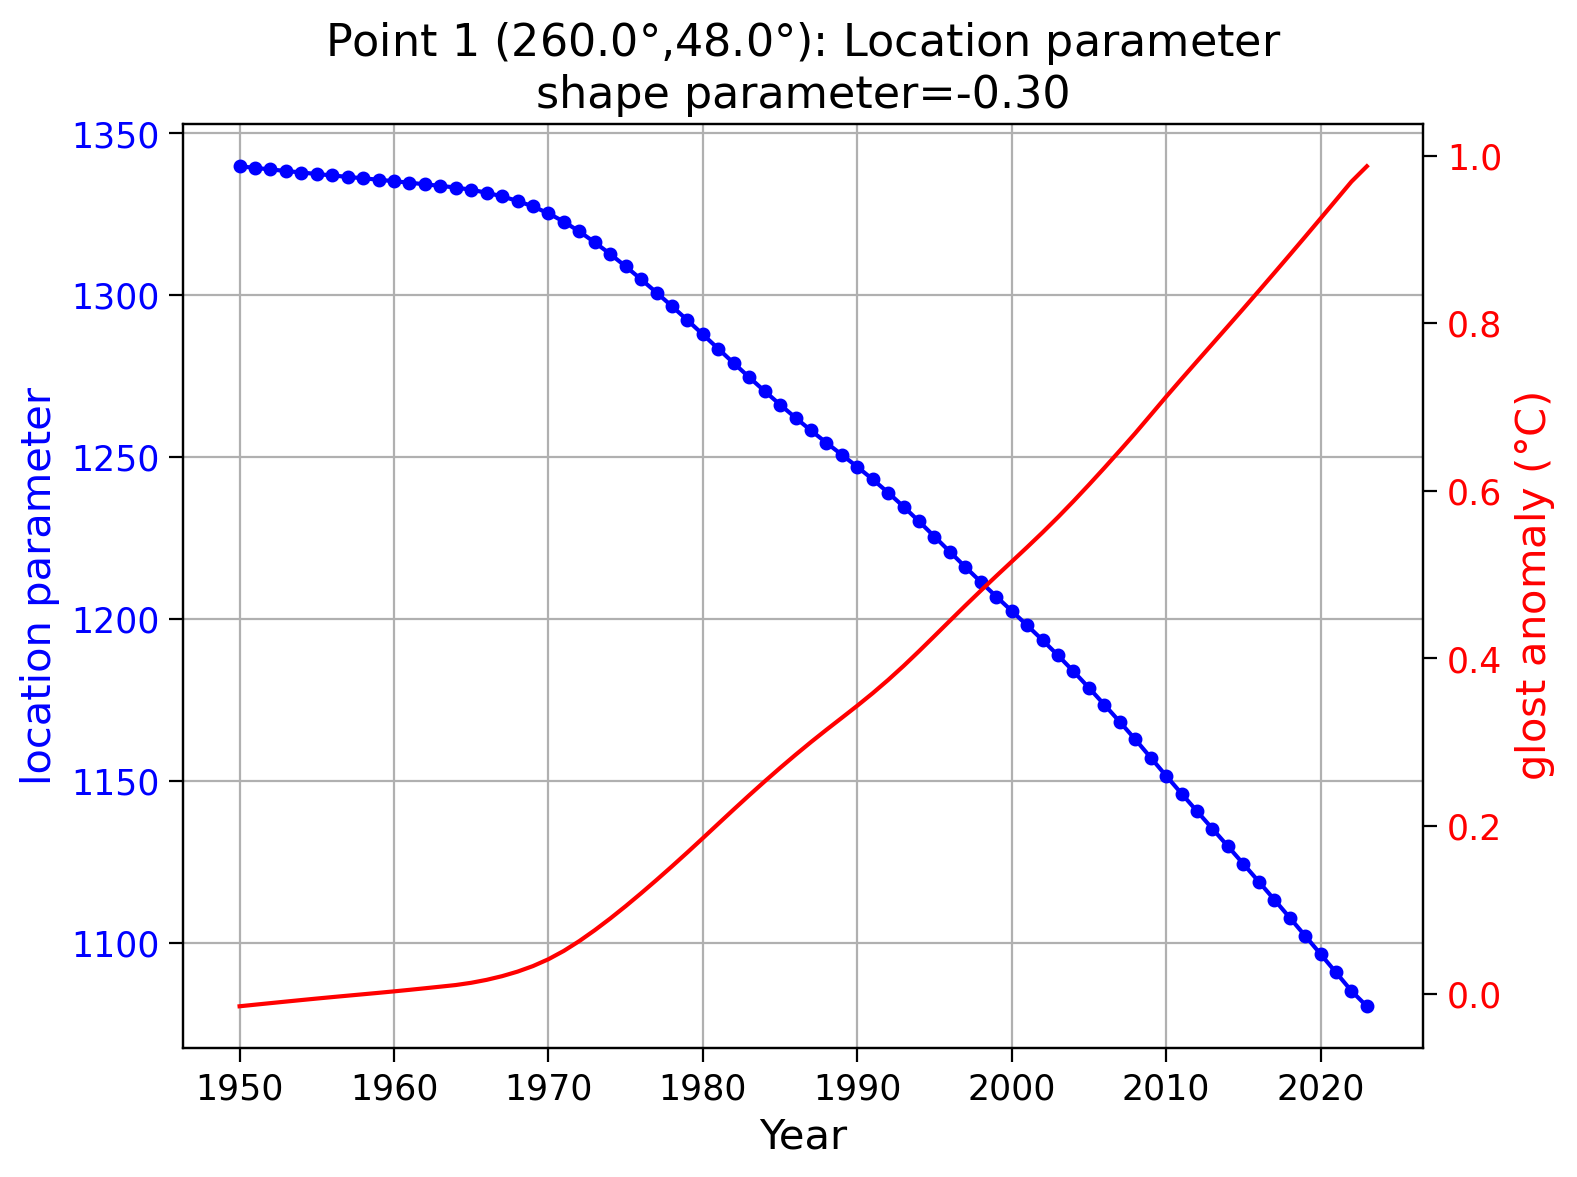

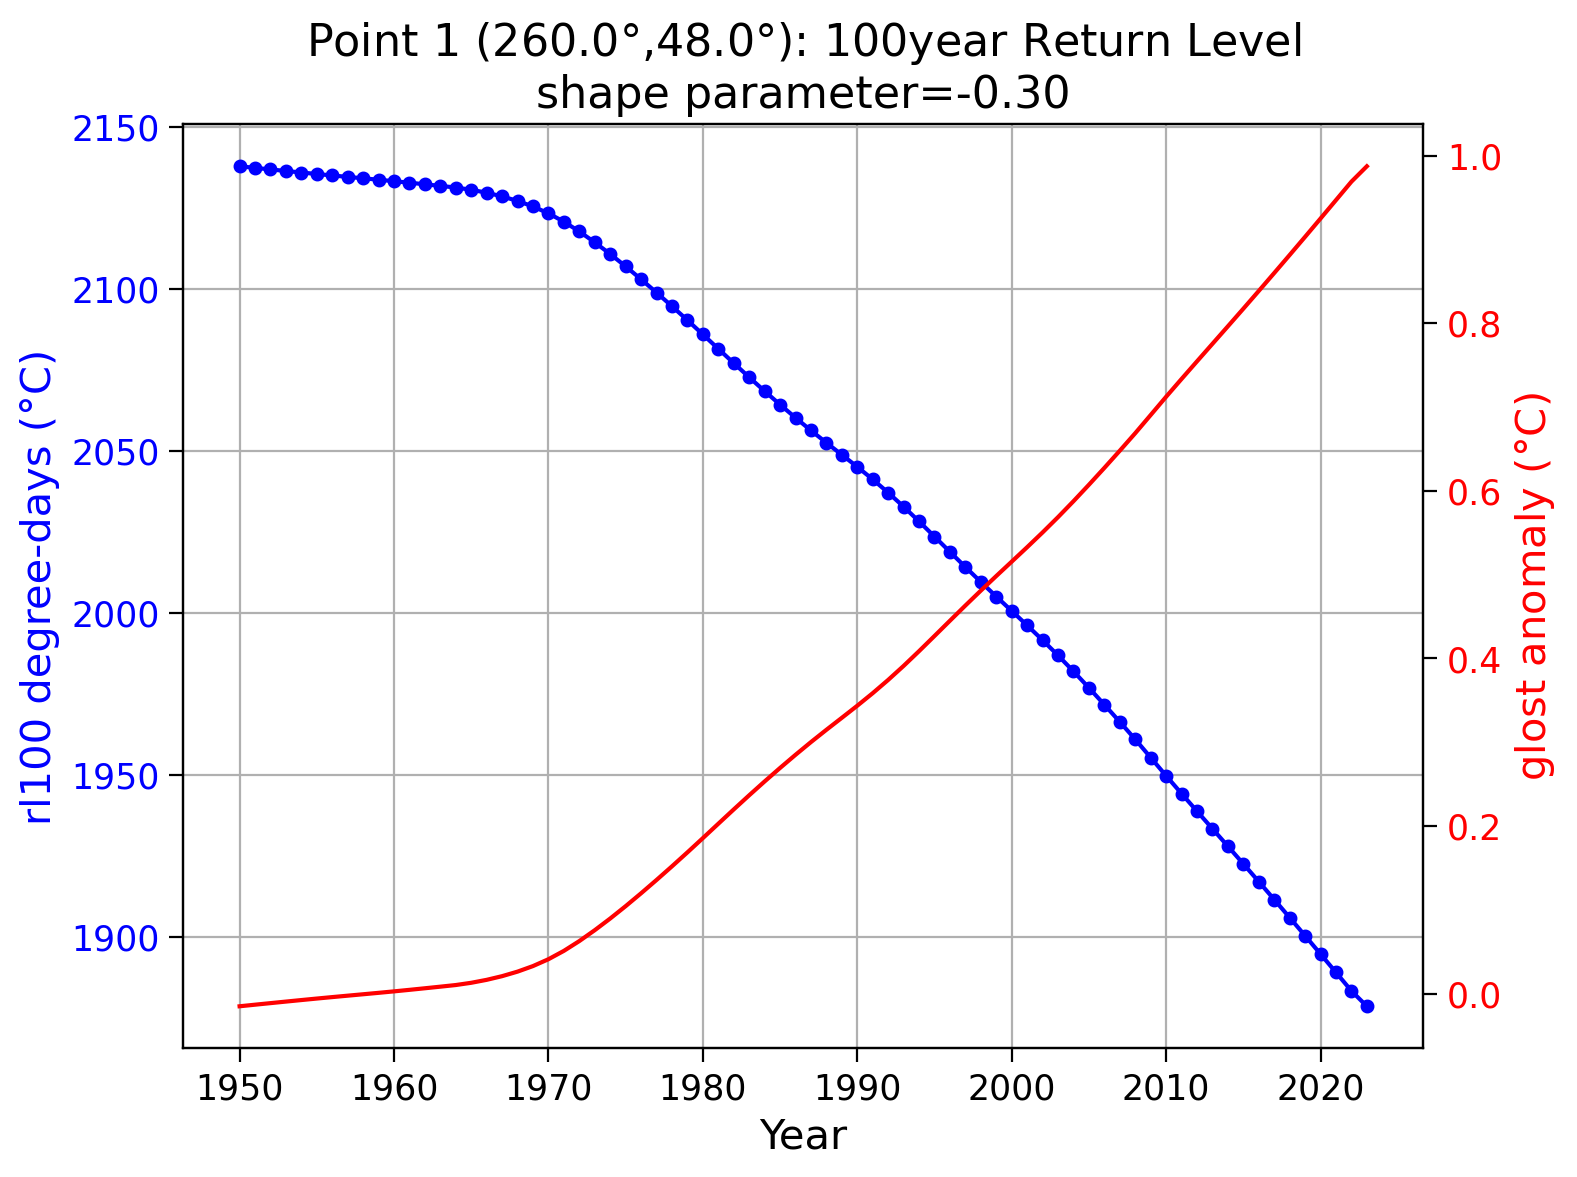

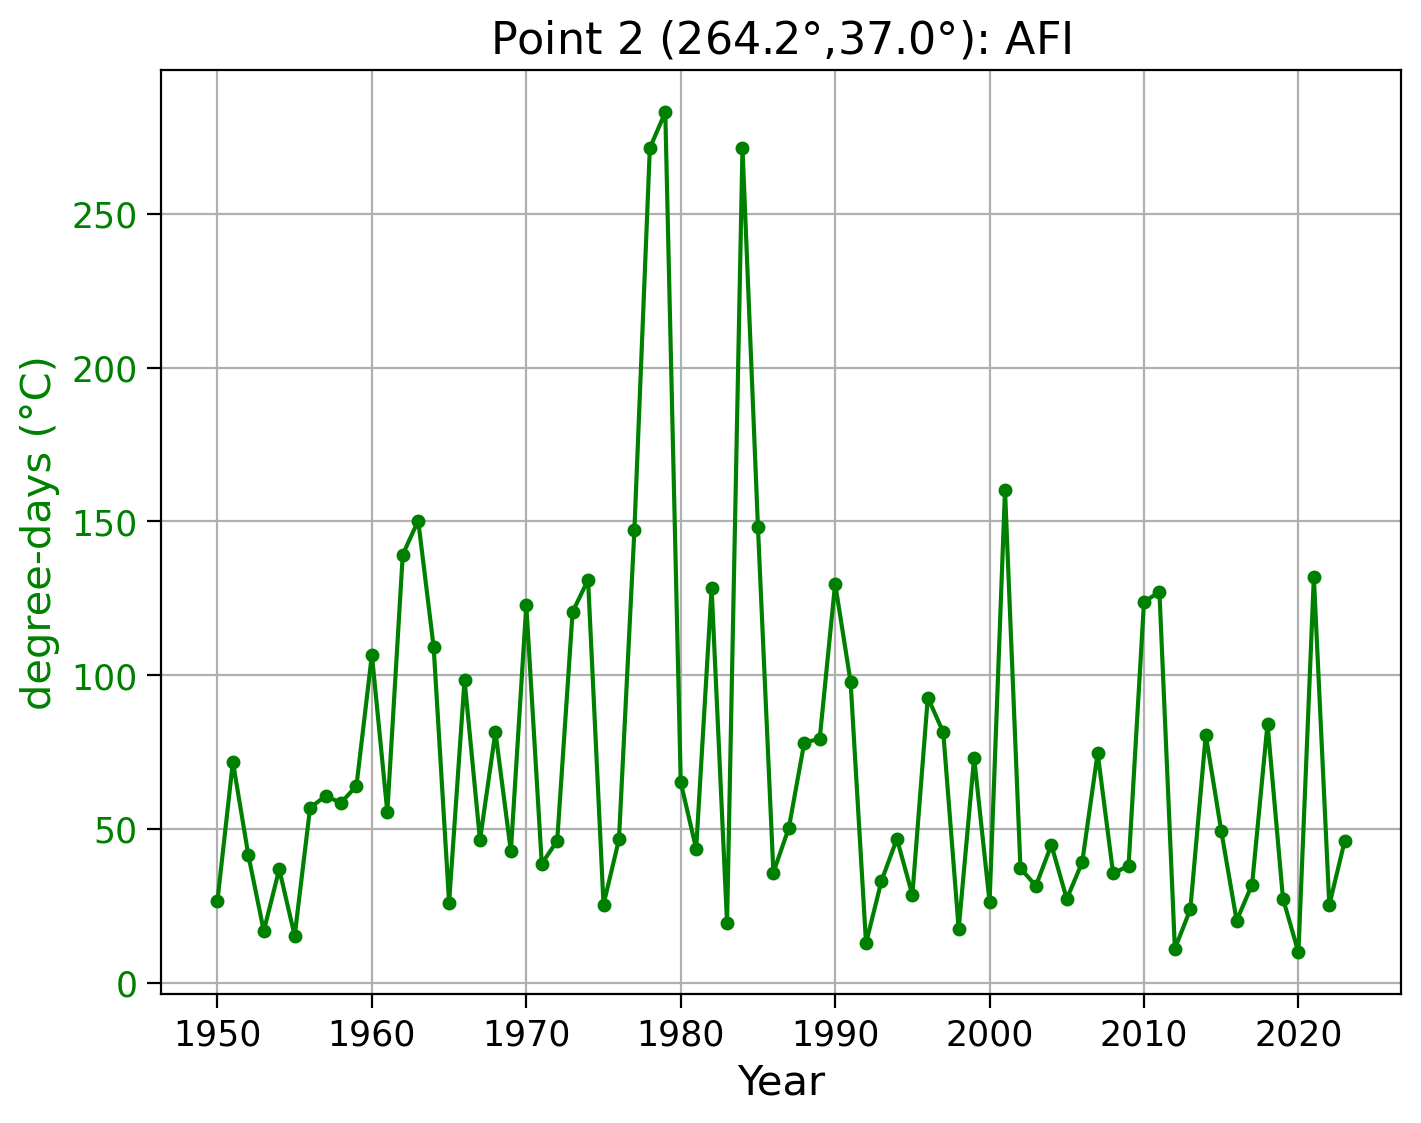

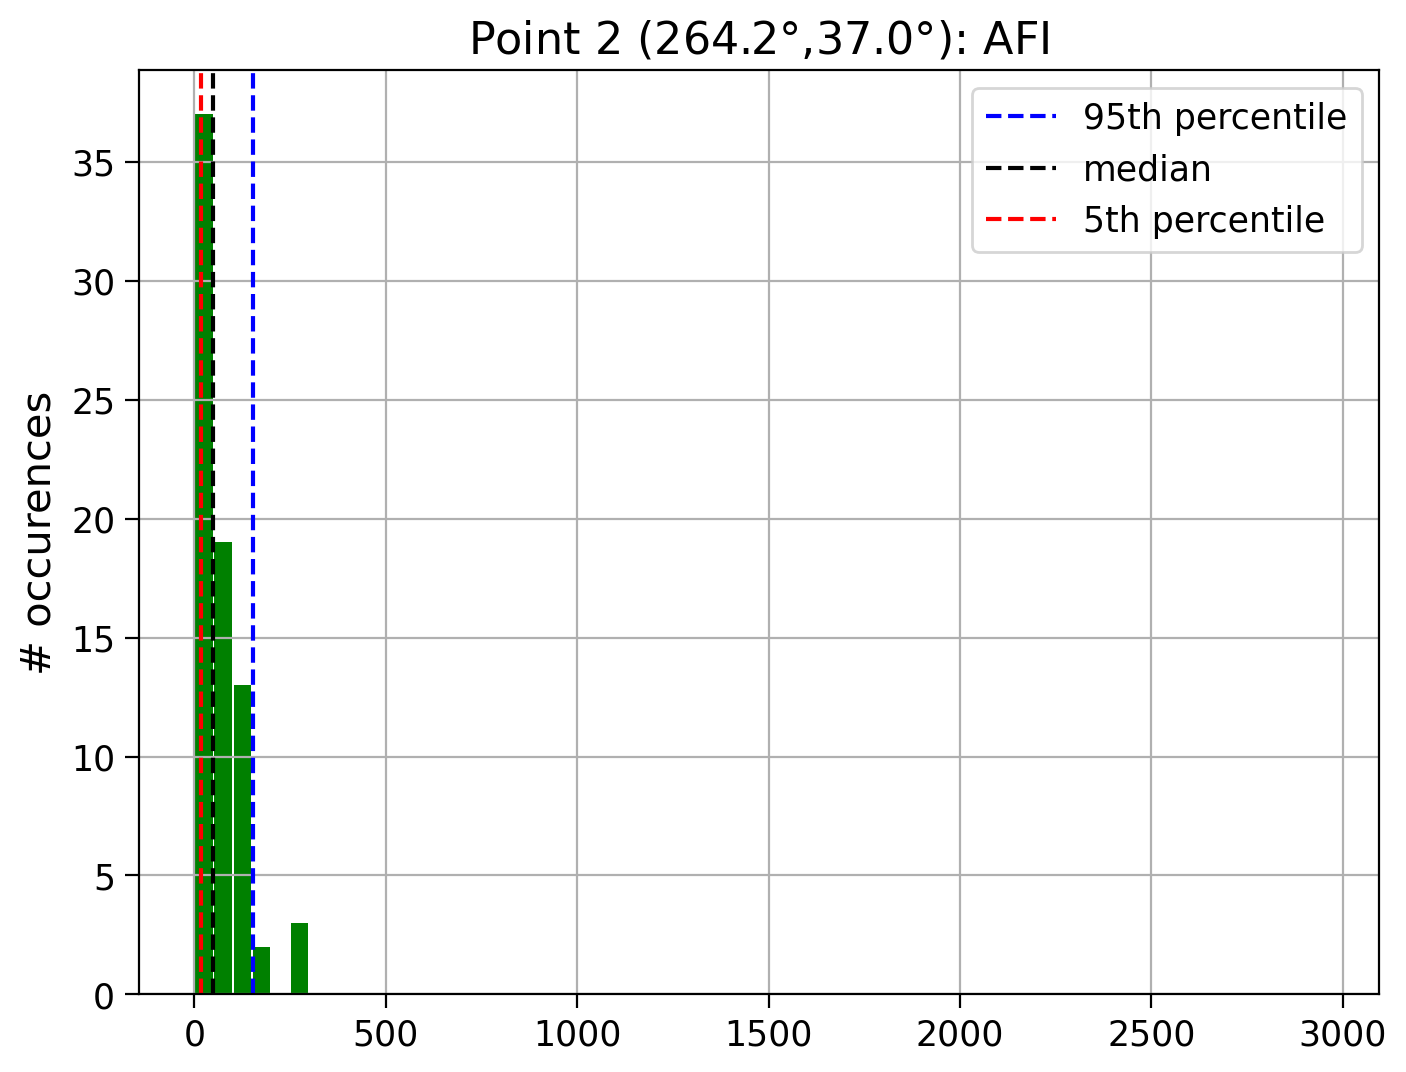

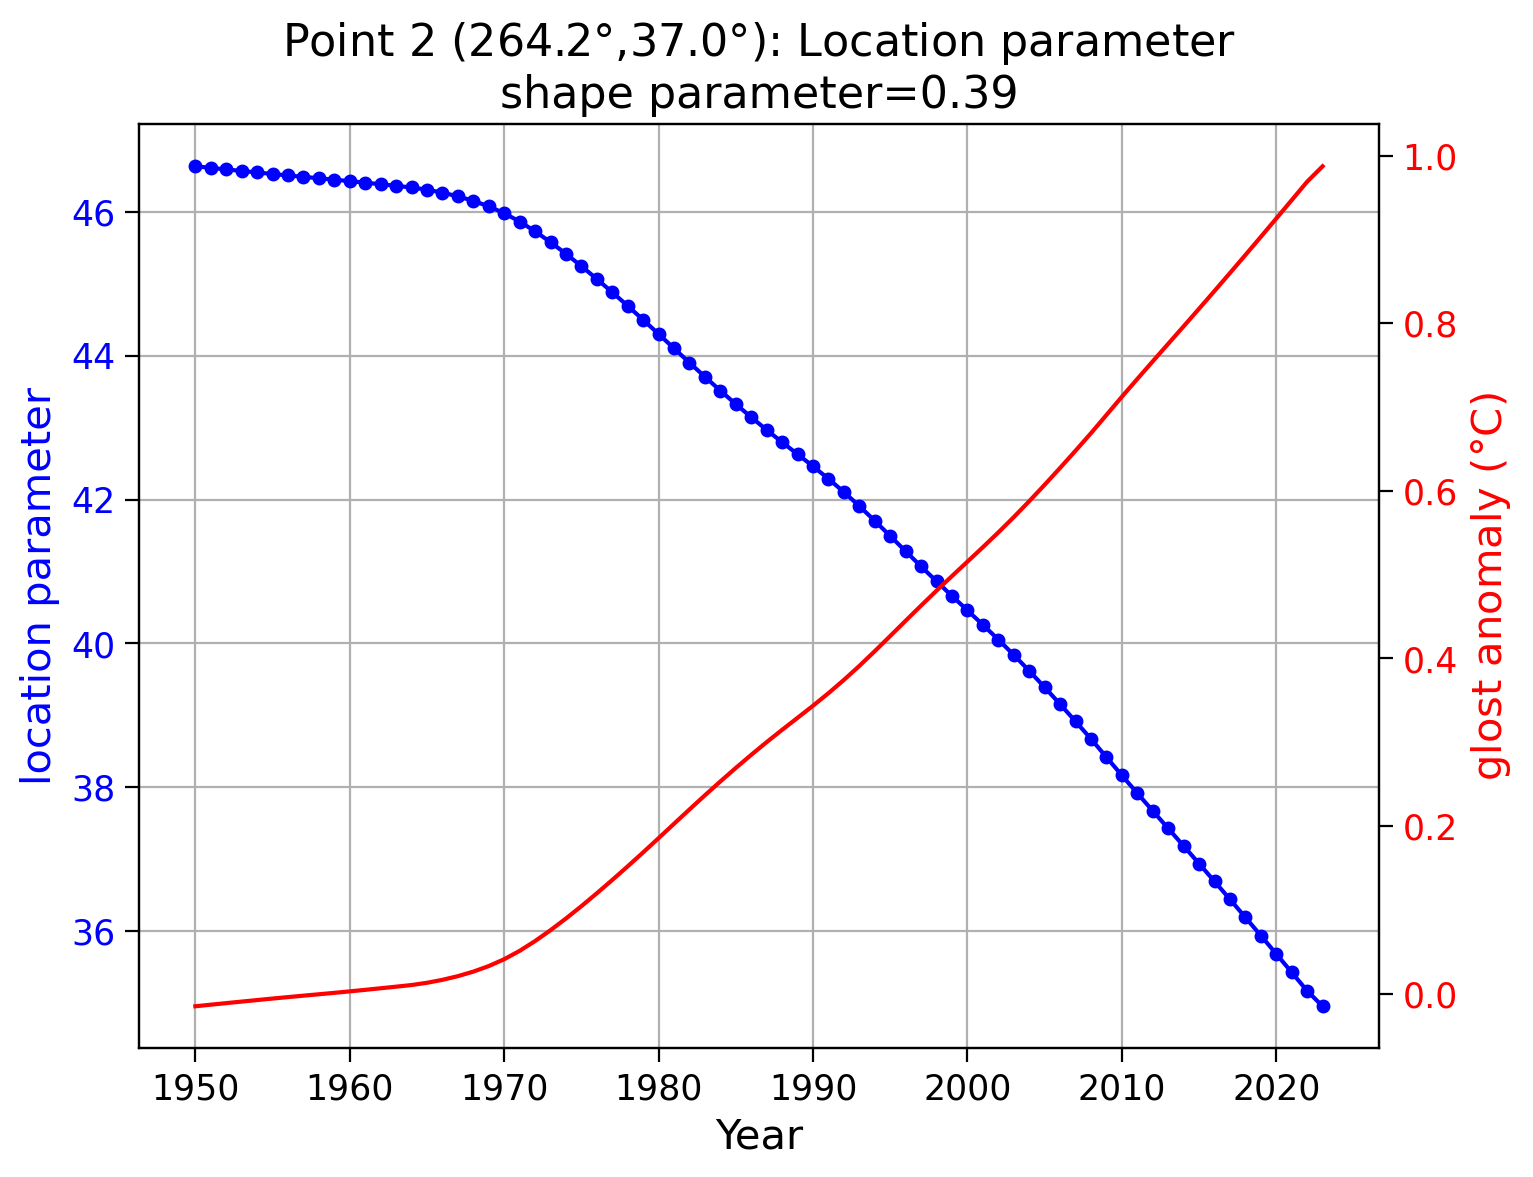

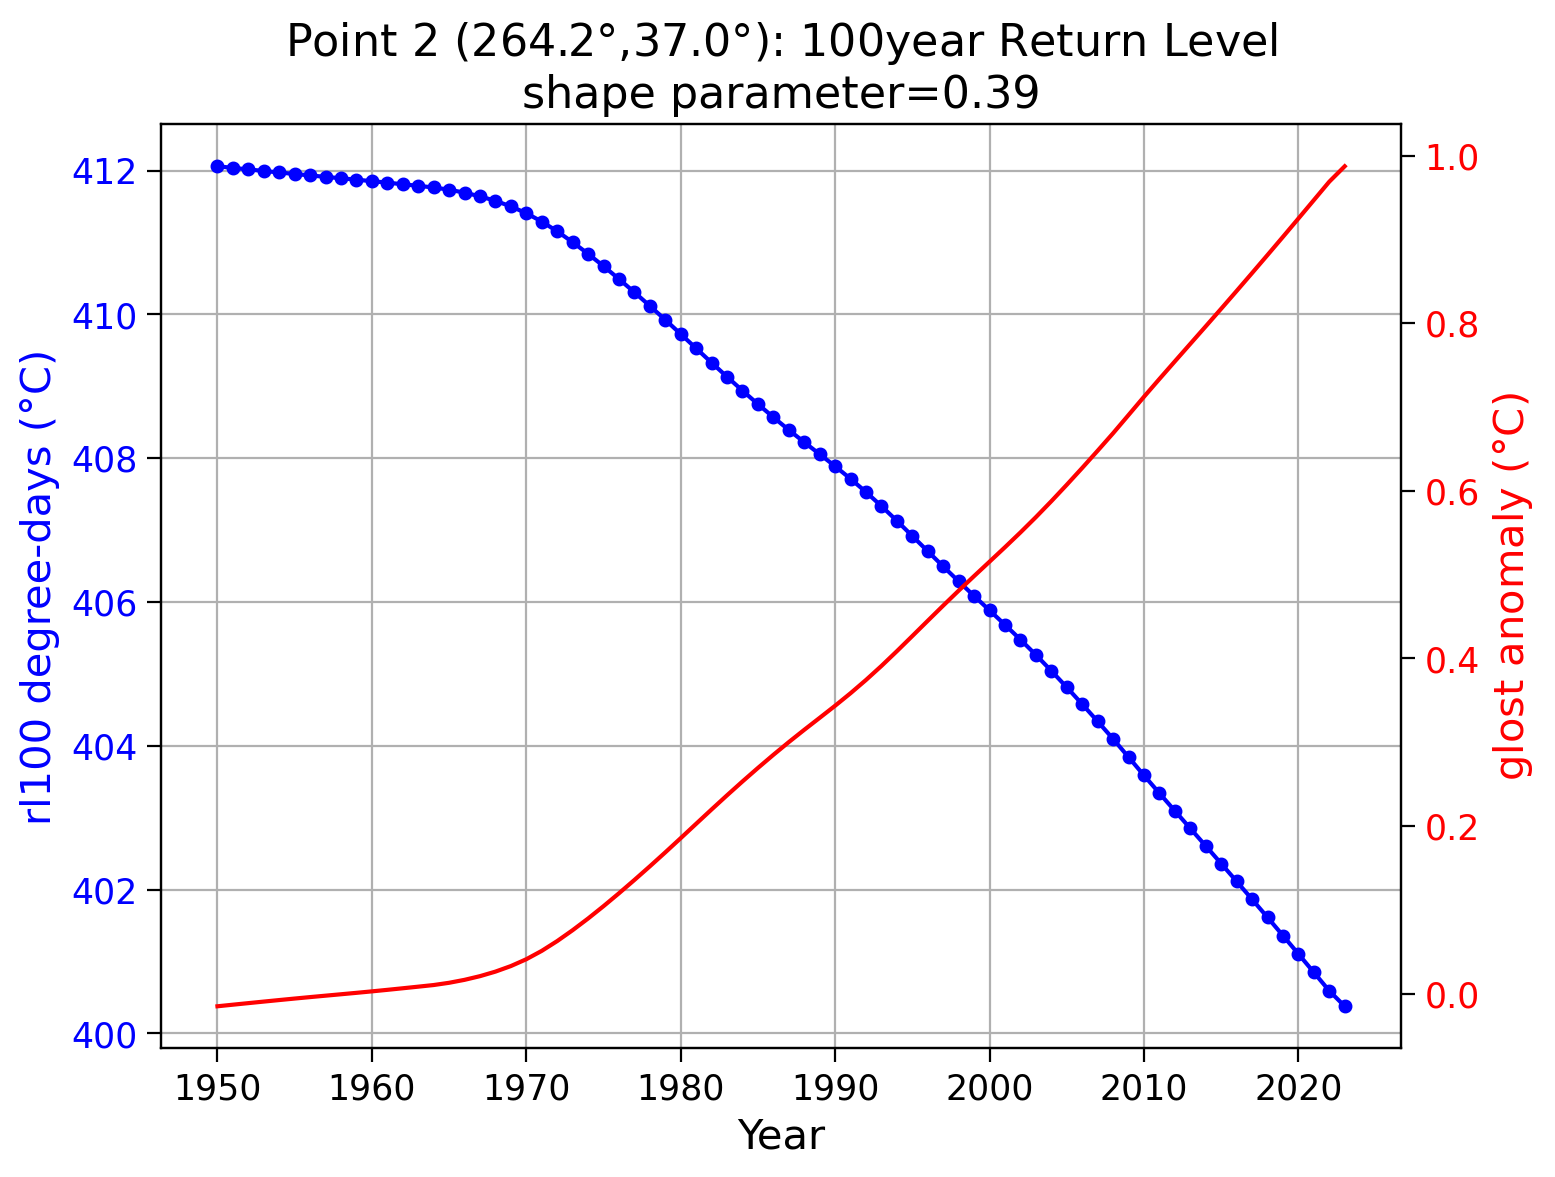

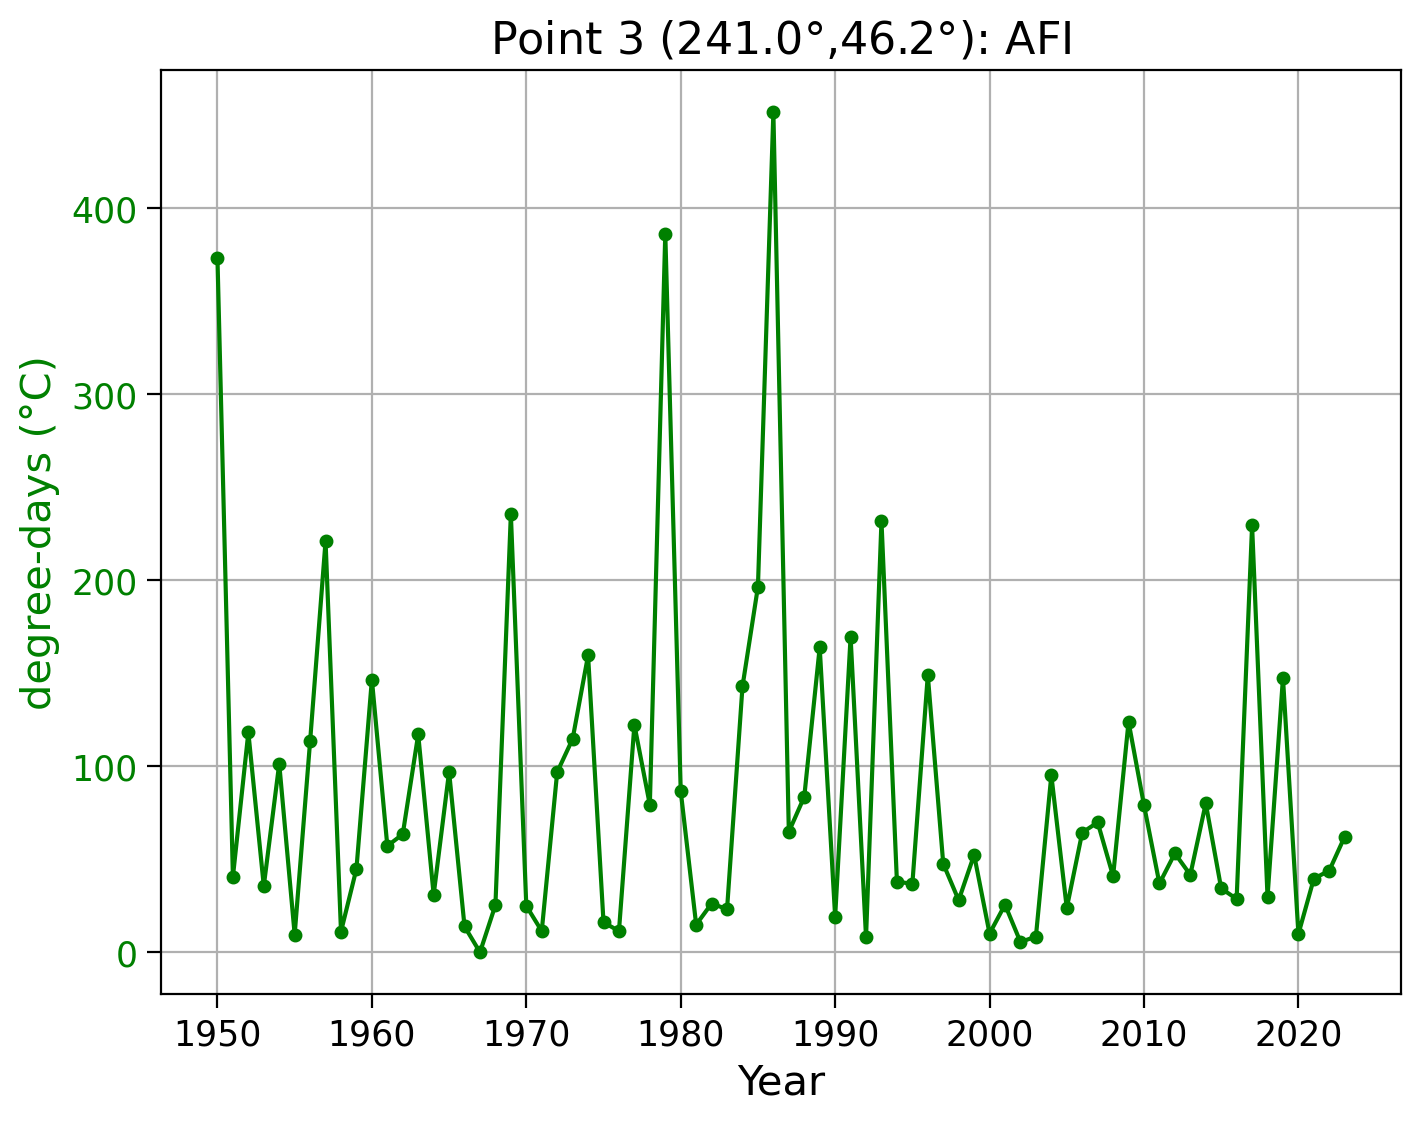

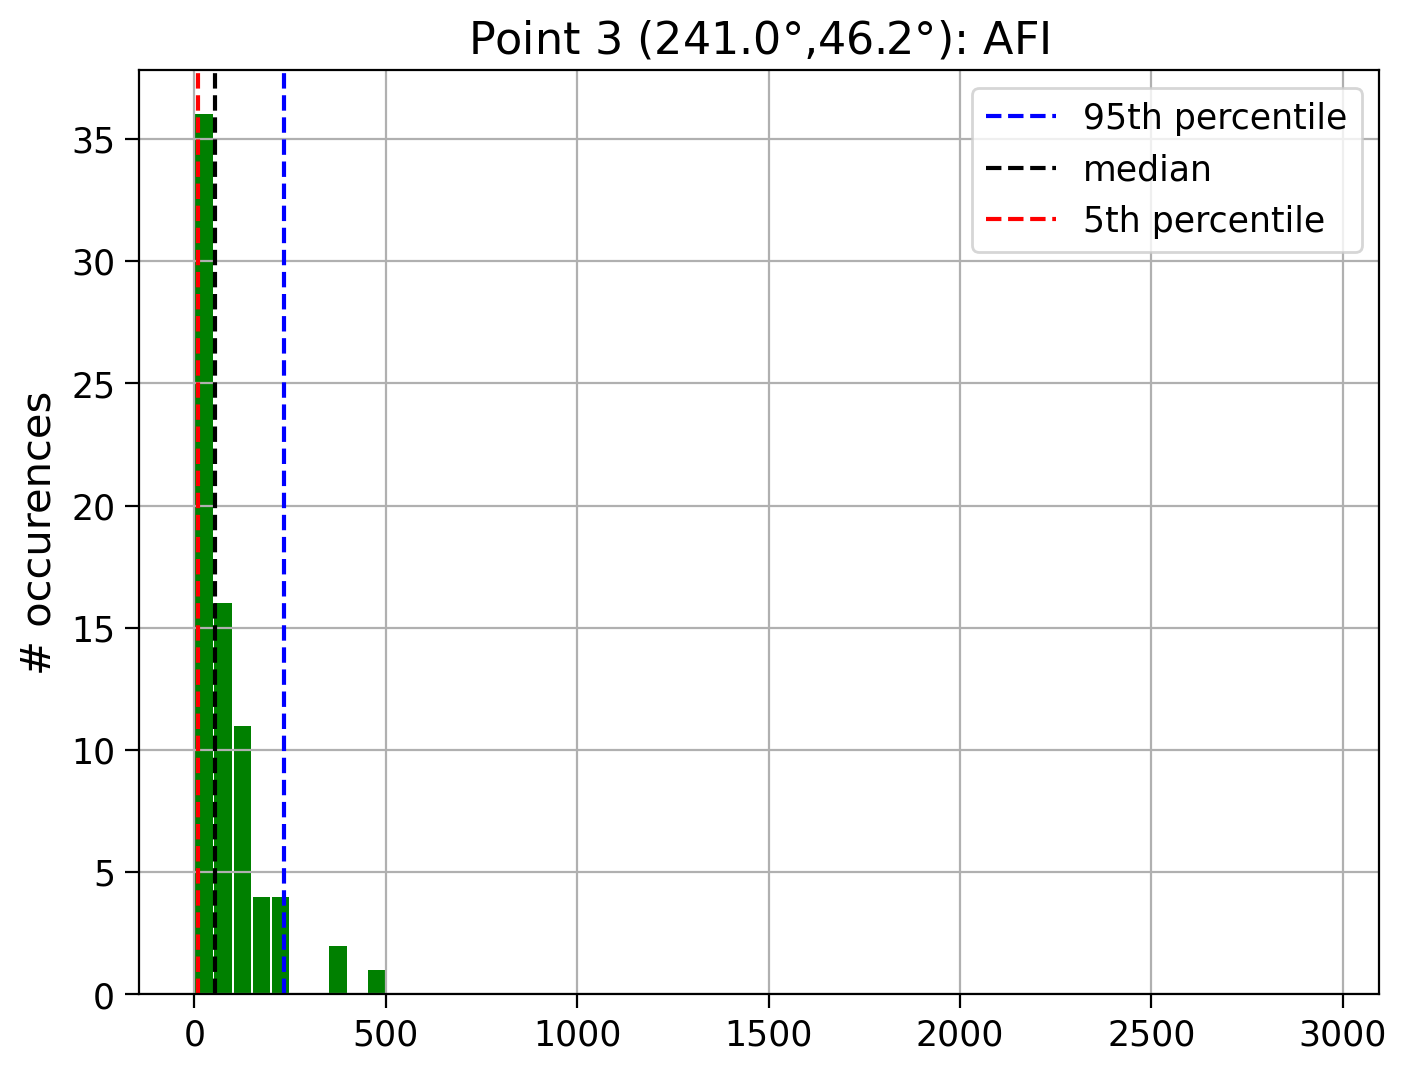

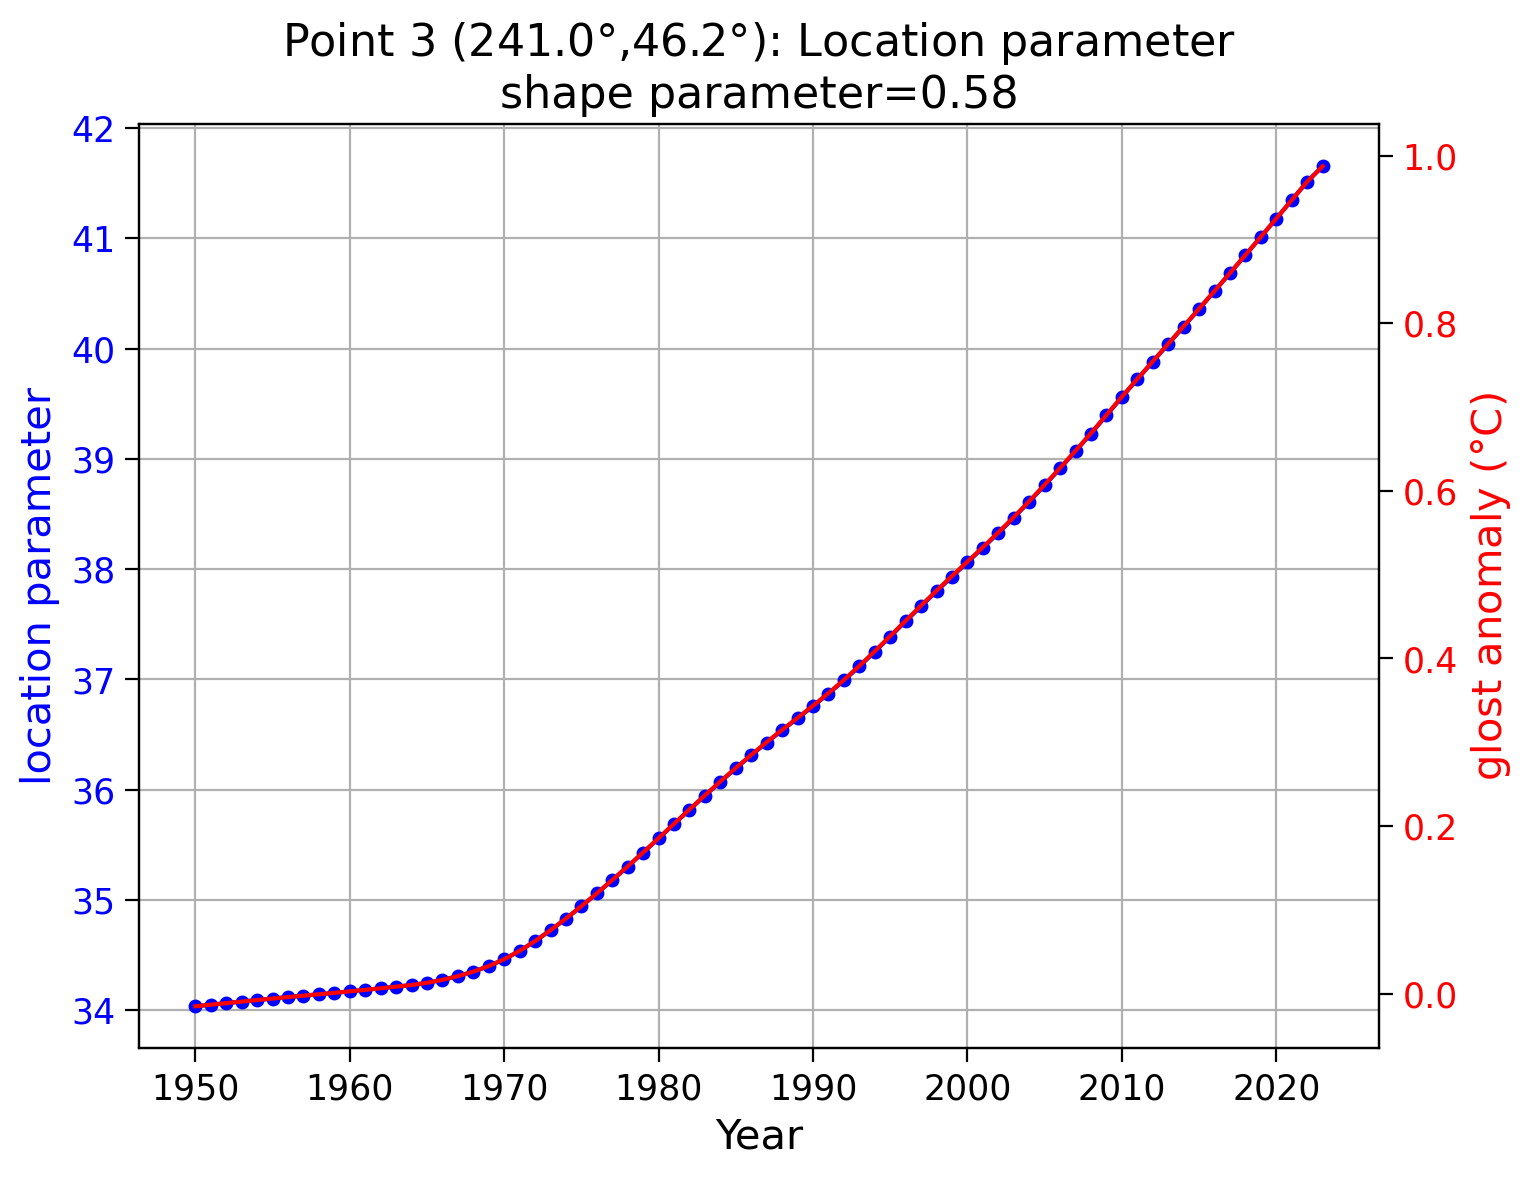

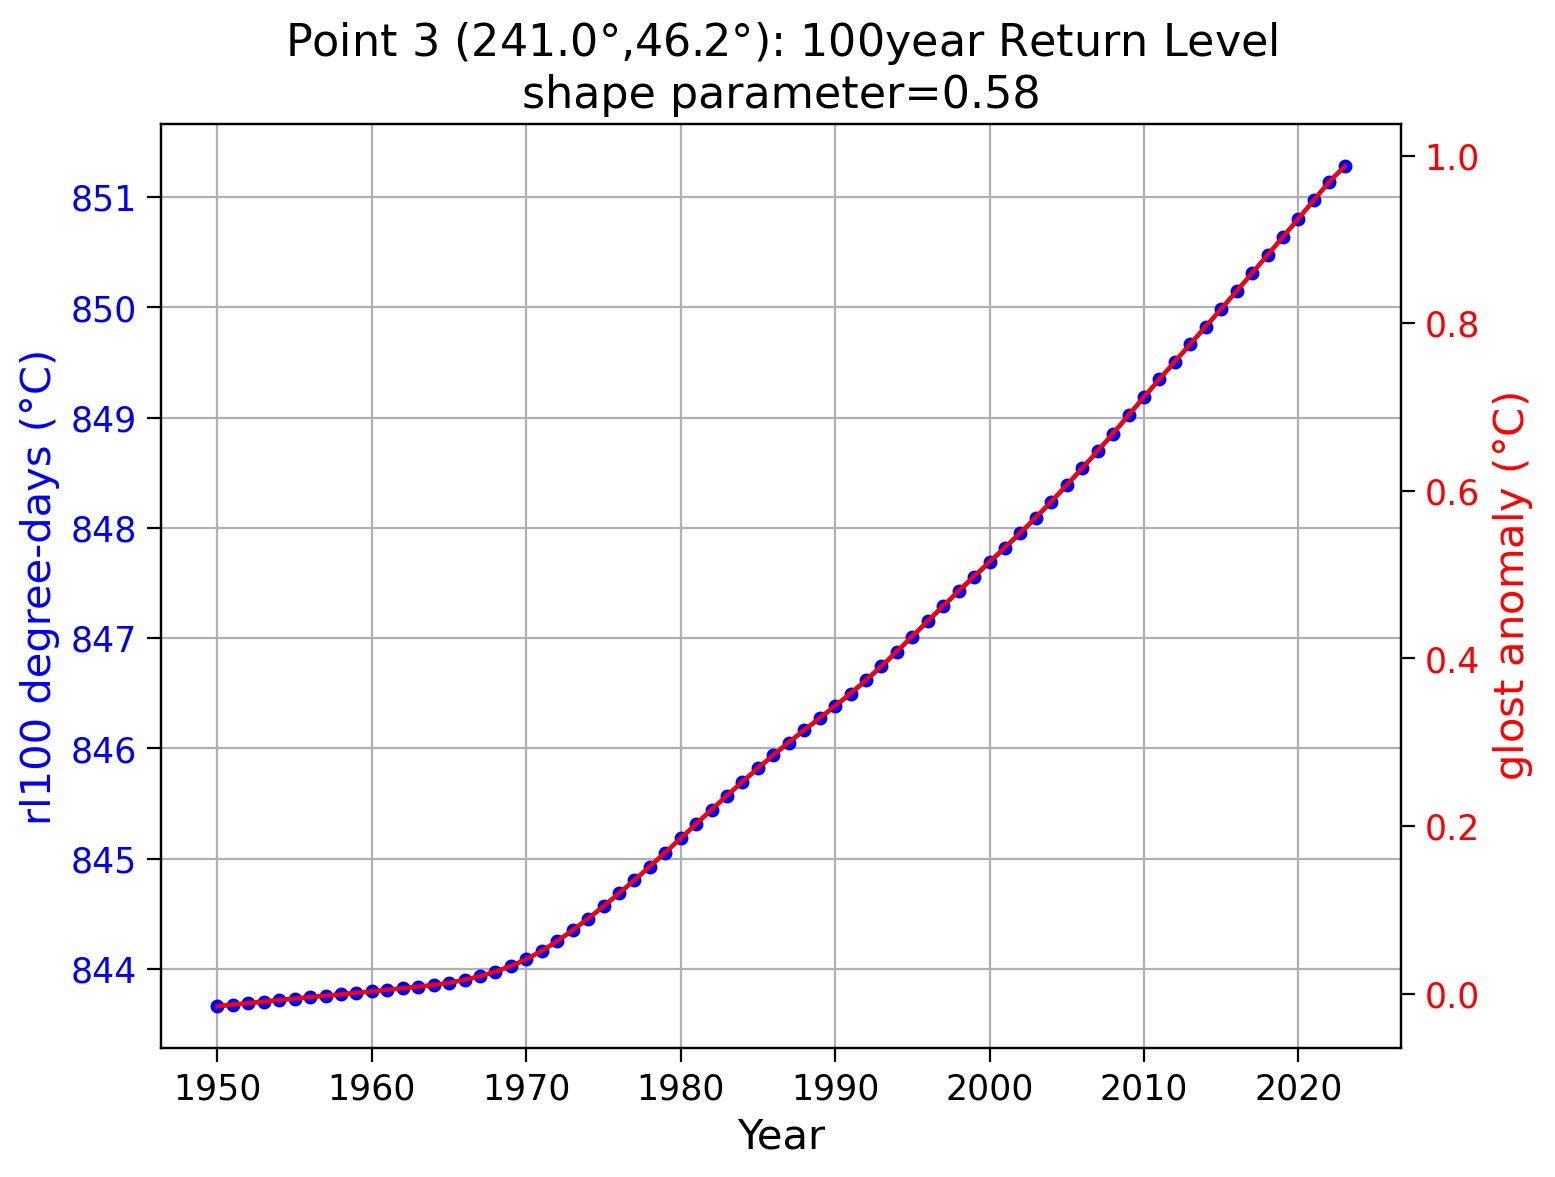

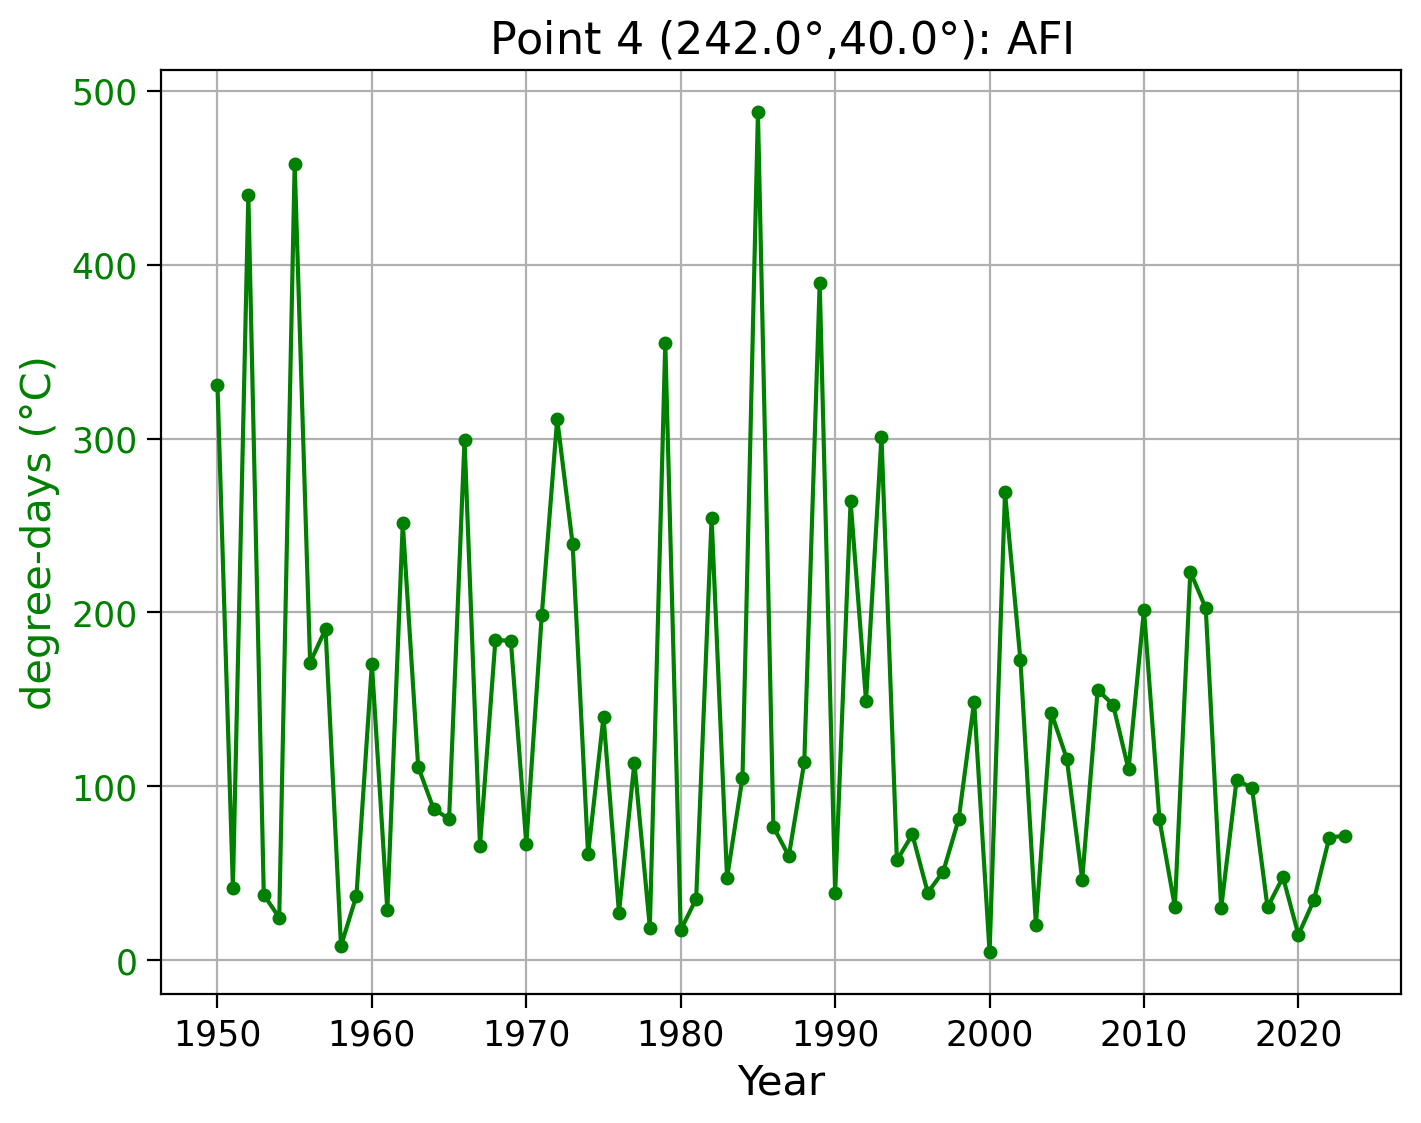

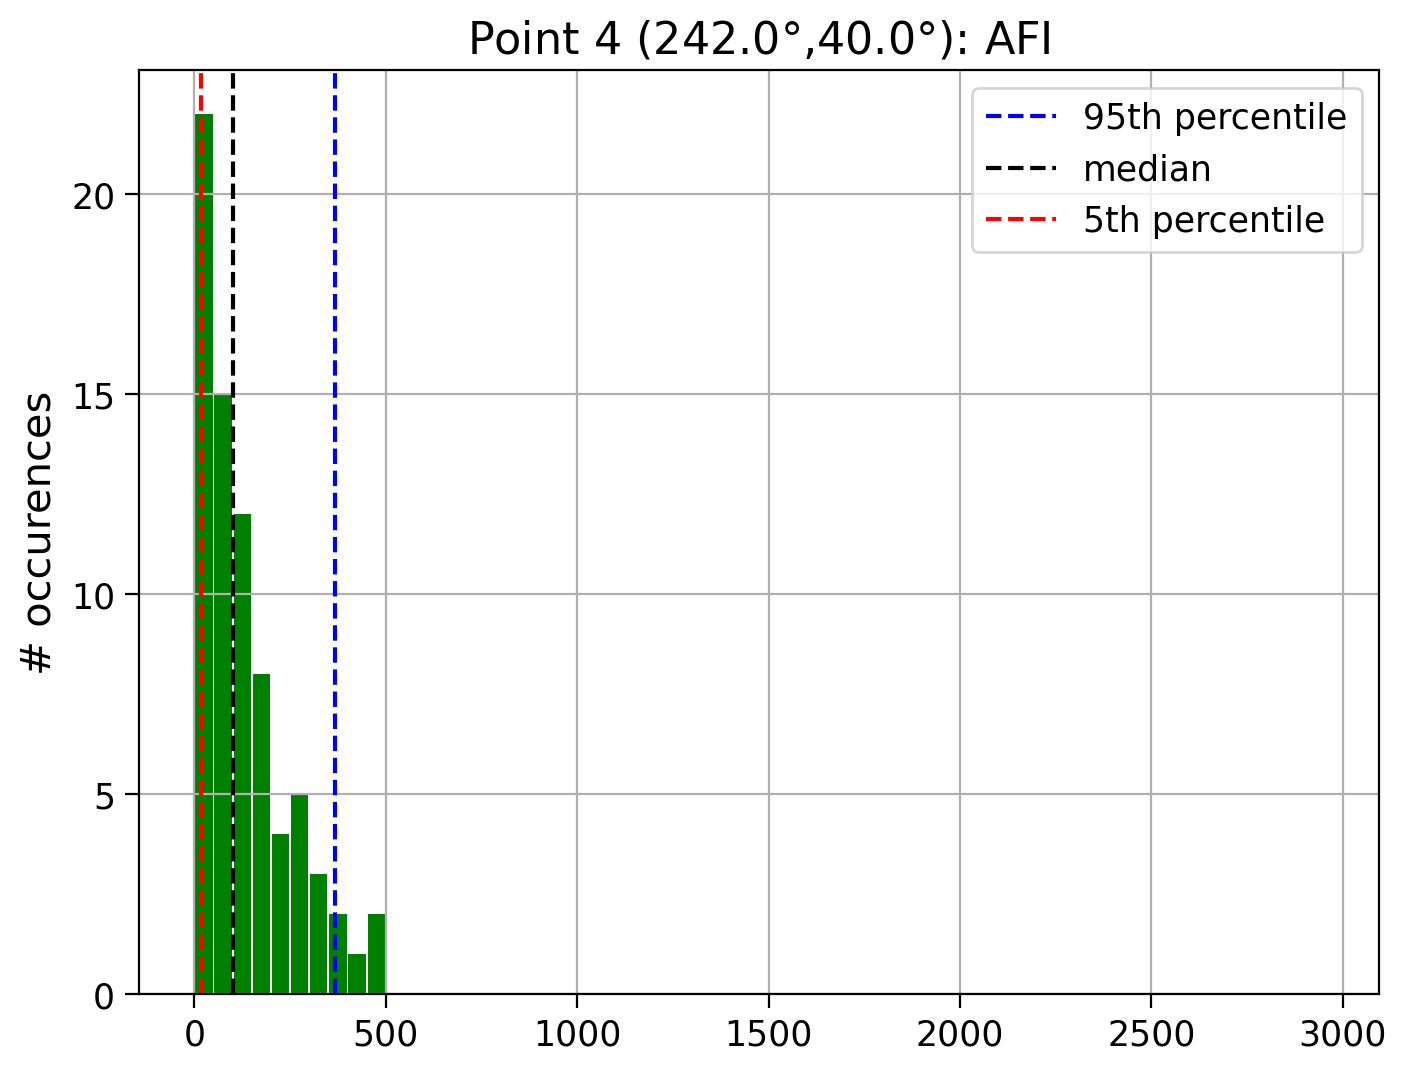

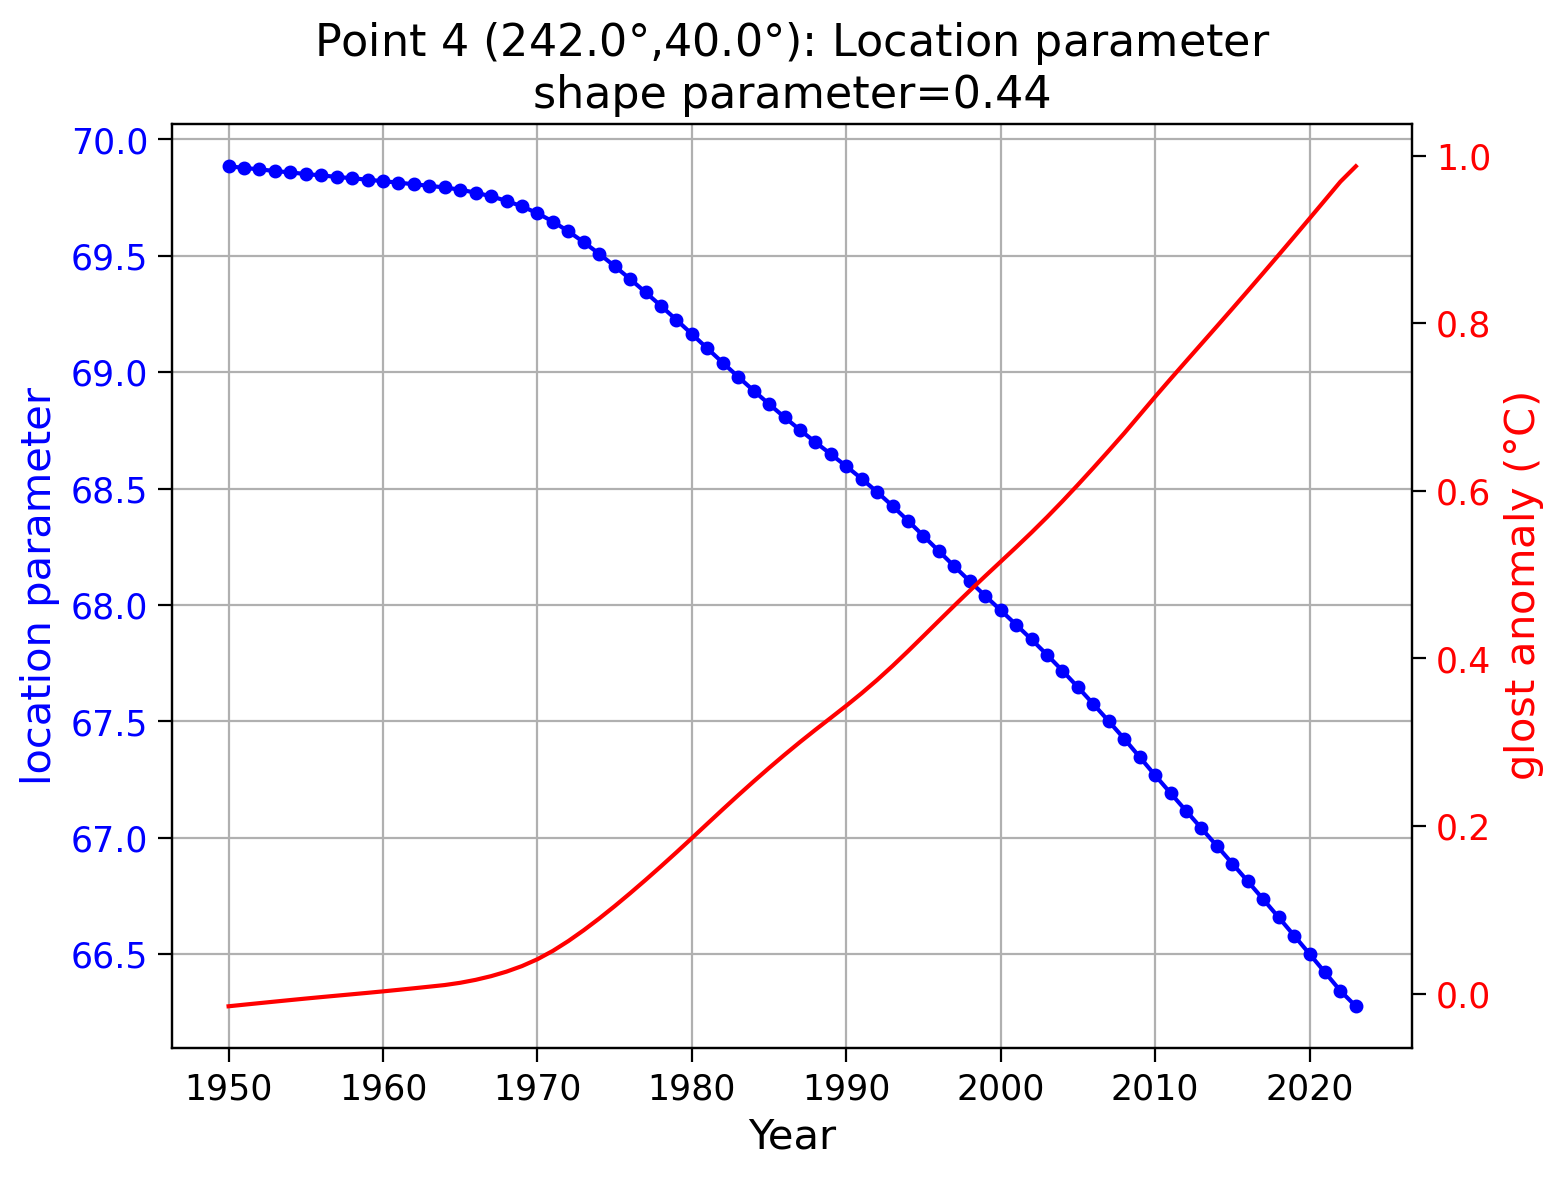

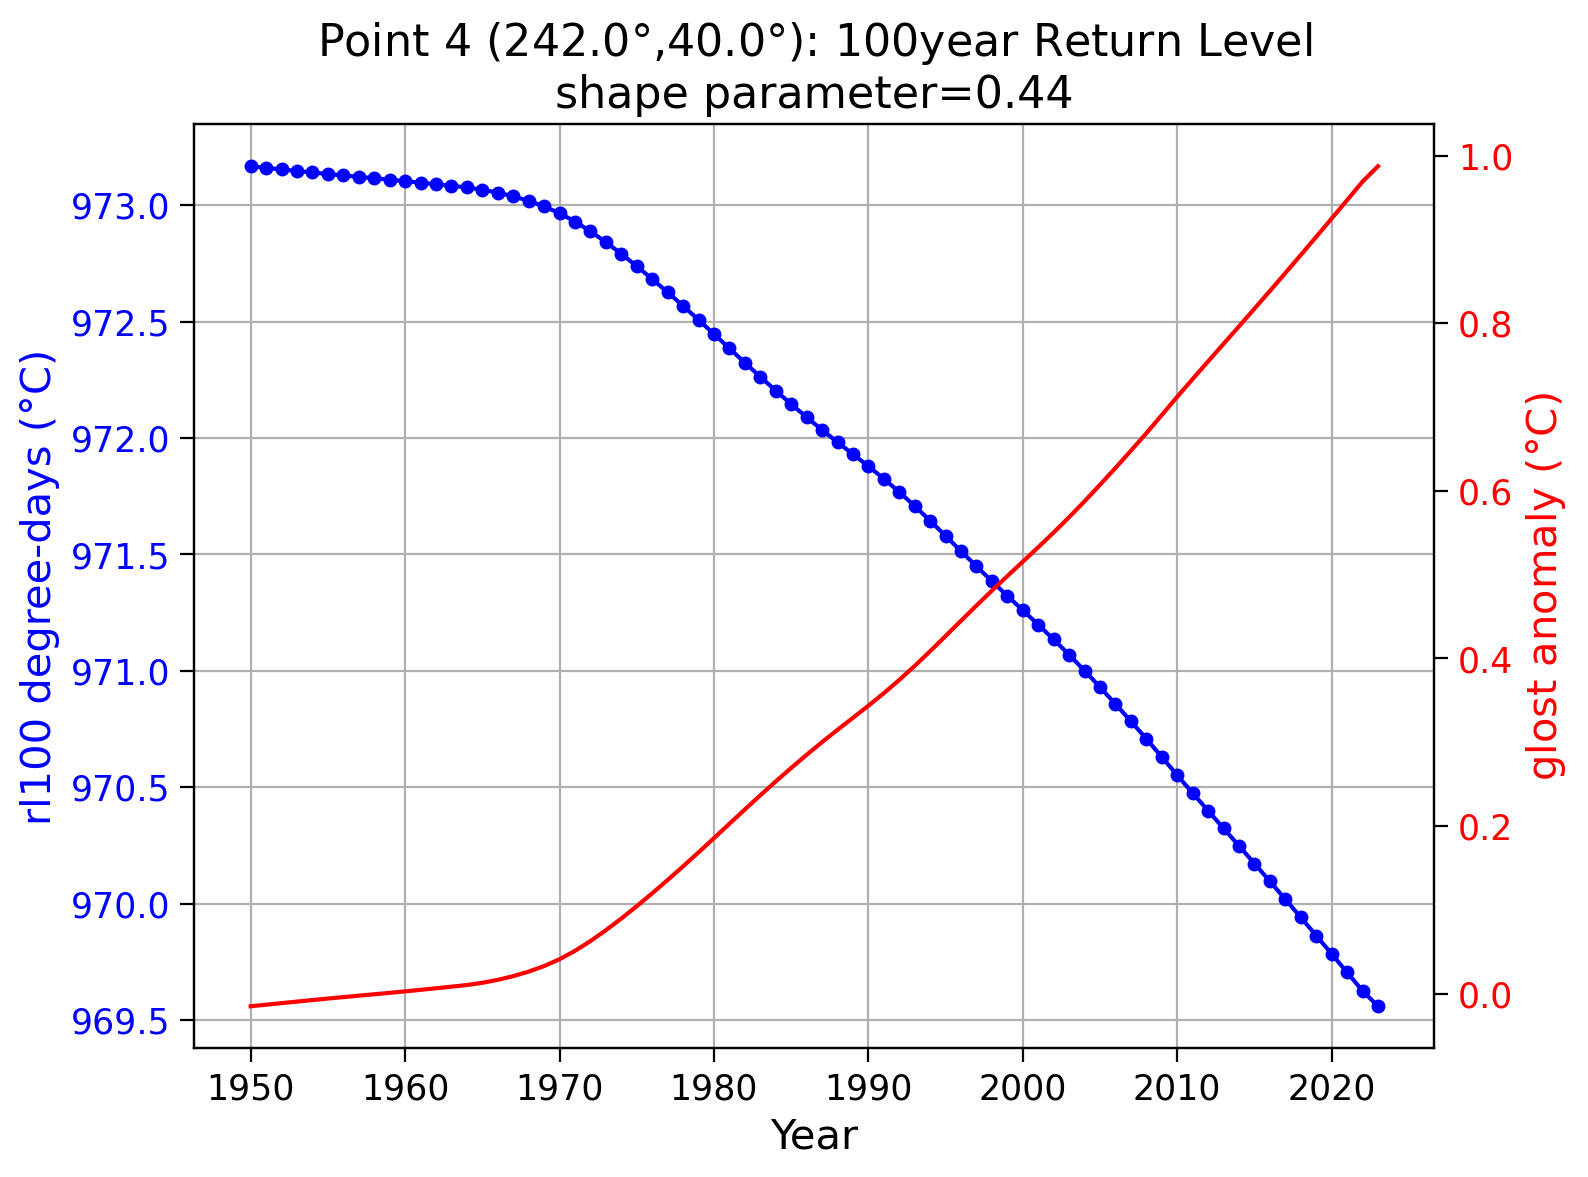

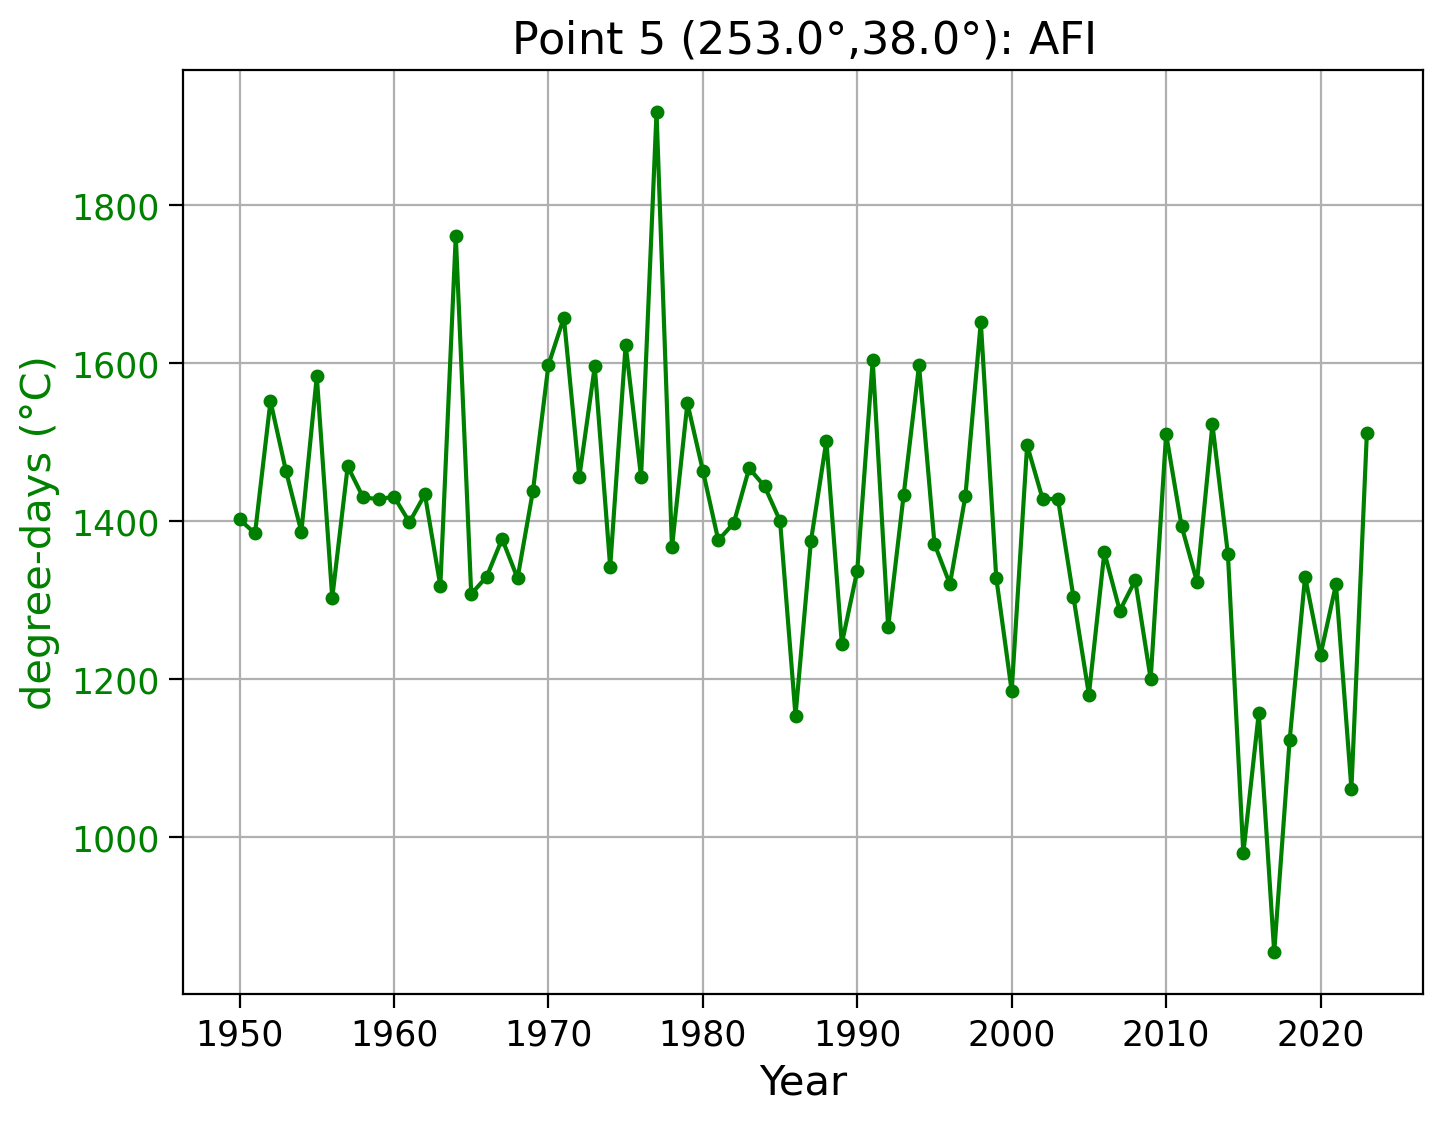

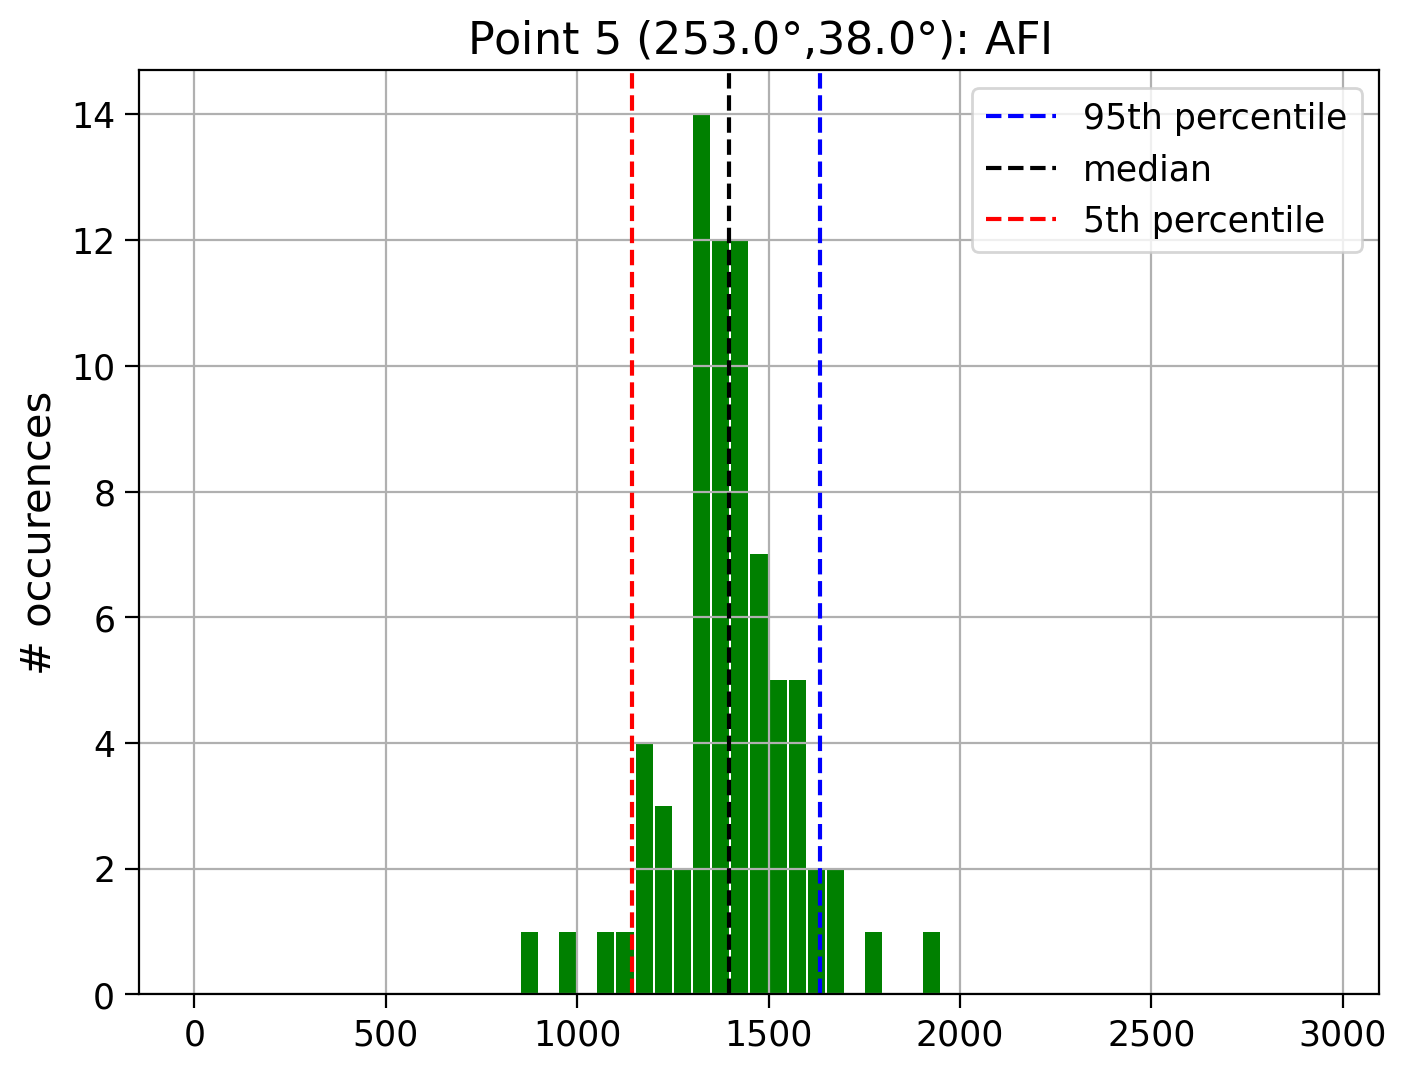

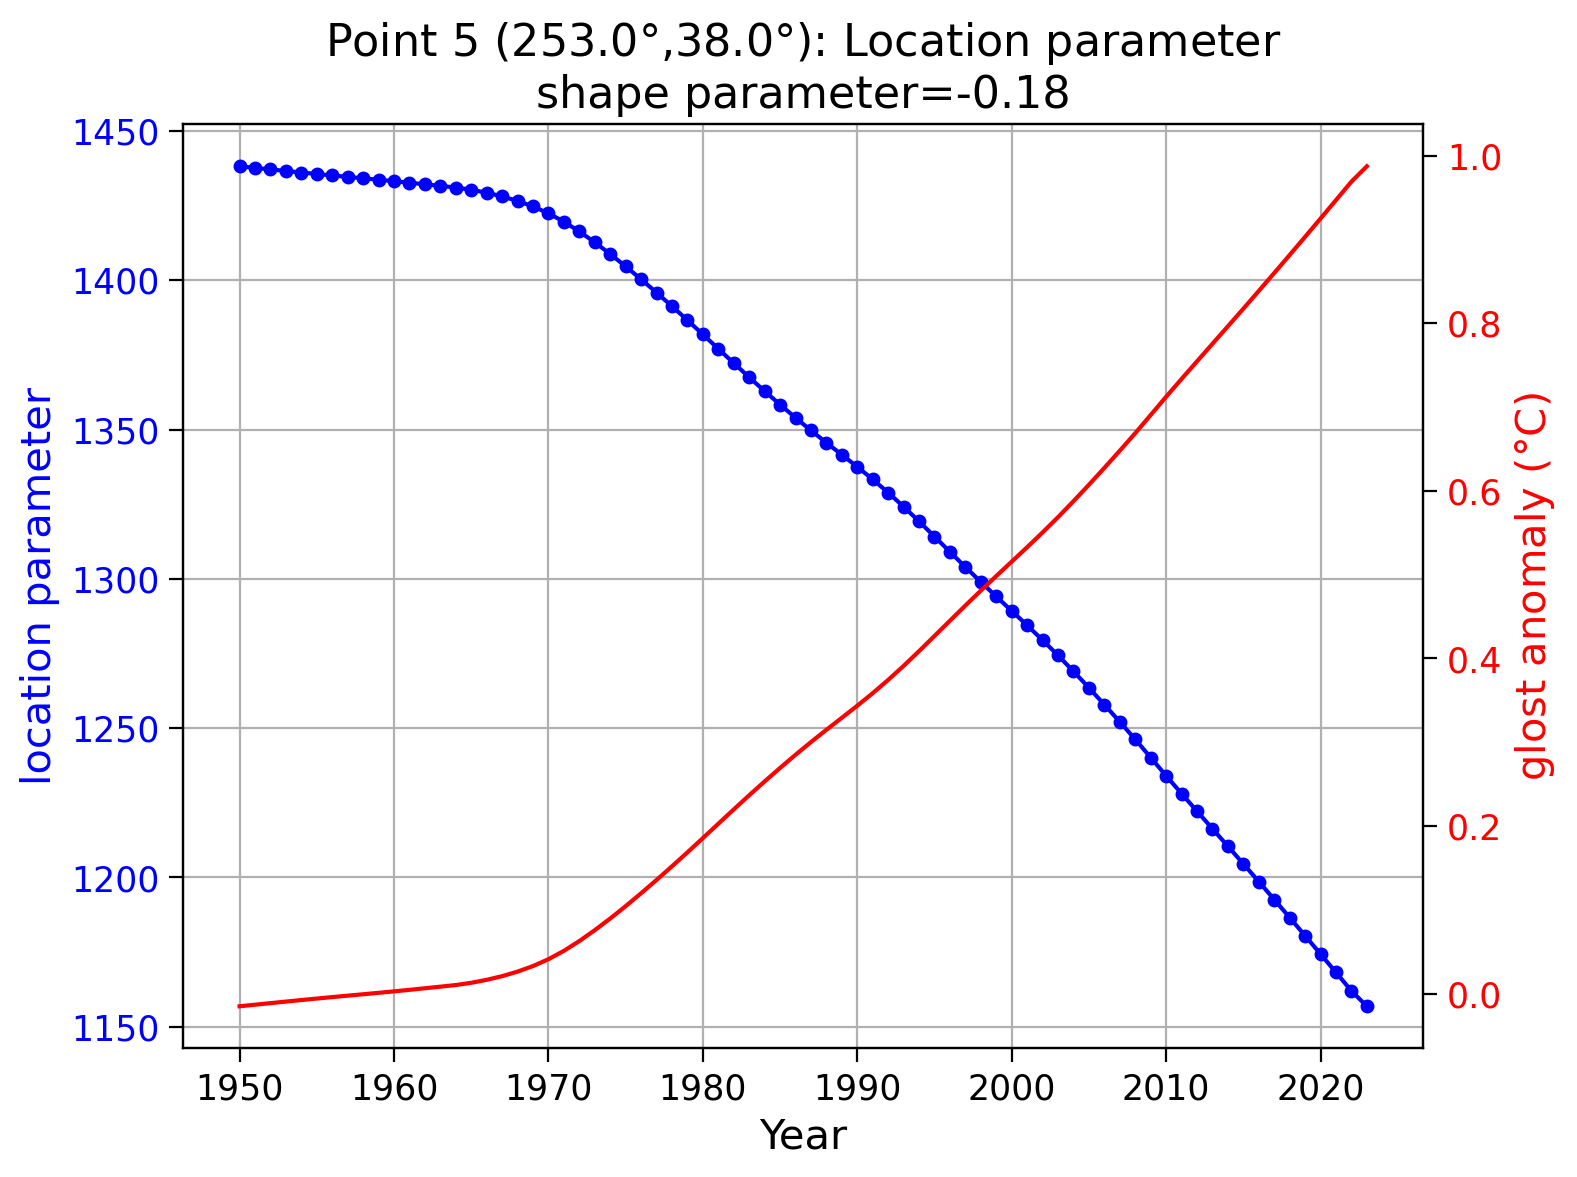

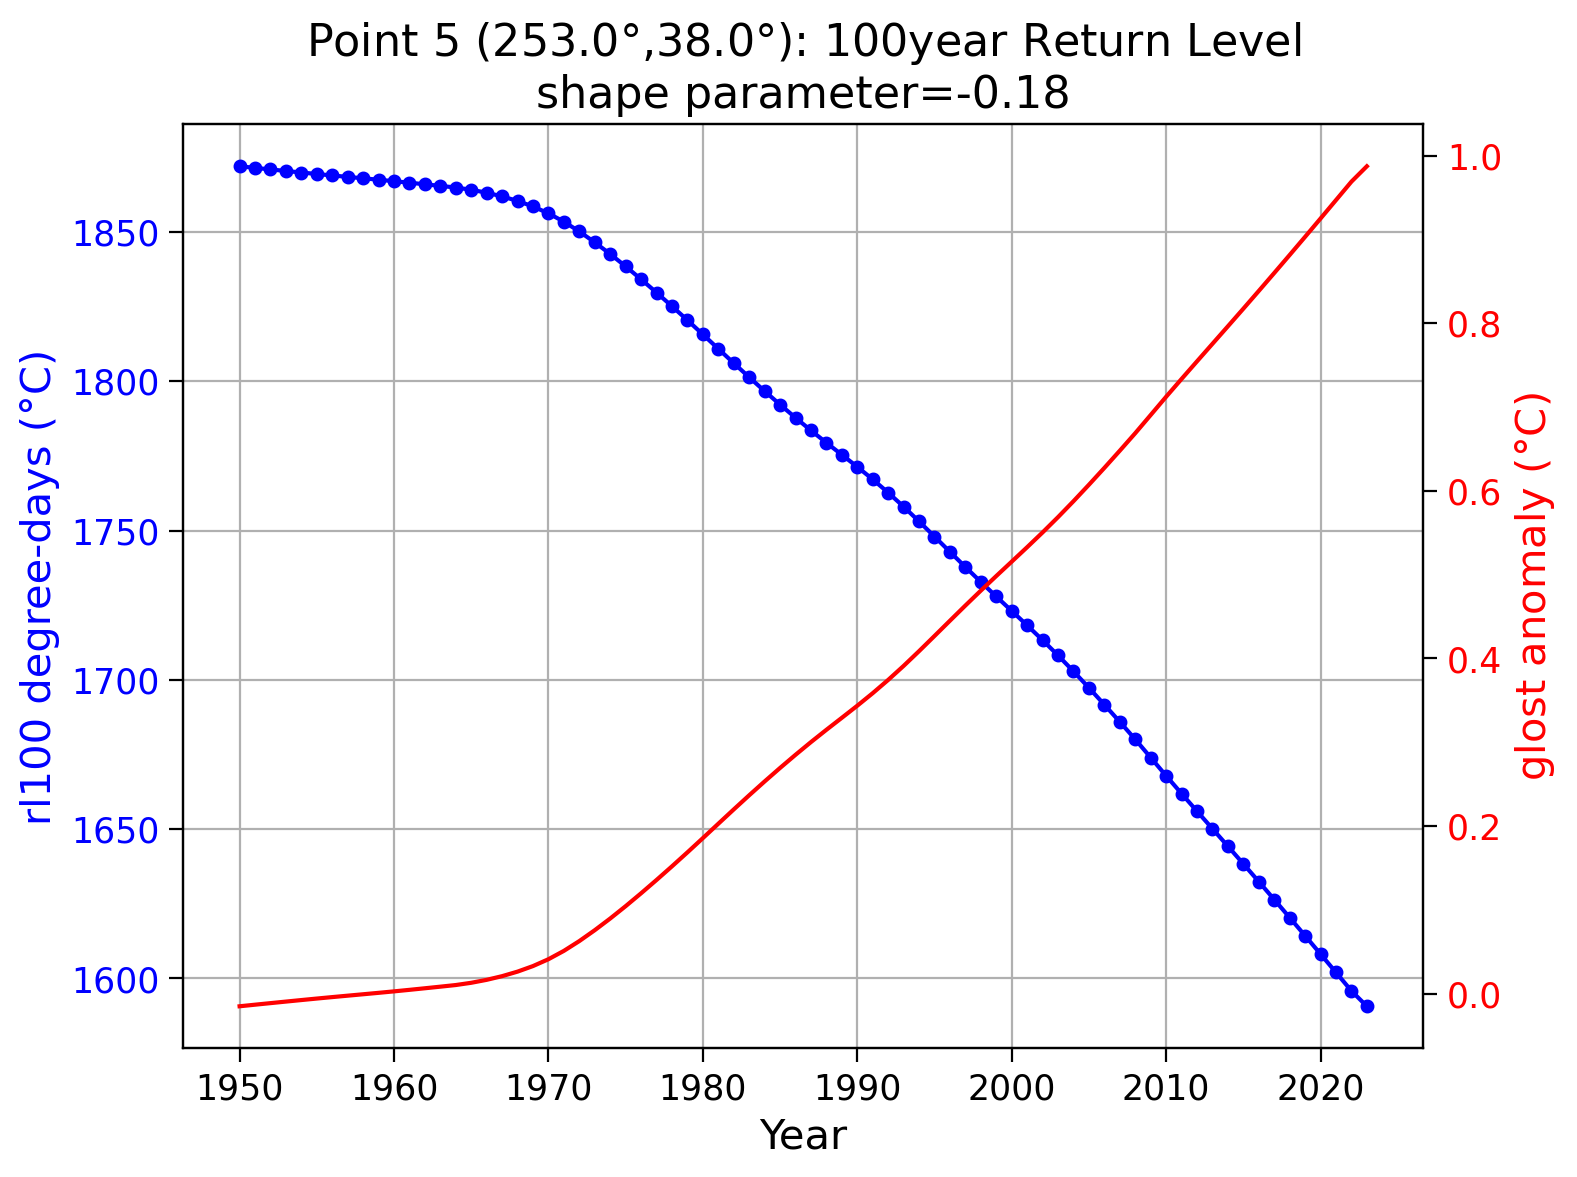

In [ ]:
bins=np.arange(0,3000,50)

for ij in range(0,len(ptlon)):
  ilon=ptlon[ij]
  ilat=ptlat[ij]
  # Extract values for boxes
  dsij=ds.sel(lon=ilon,lat=ilat).load()
  df = dsij.to_dataframe()
  df = df.reset_index()
  # Remove zeros and NAN 
  # Remove timeseries with less than 15 data (as in Bilotta et al.)
  # Save rows removed
  dfsave=df[(df['AFI'] <= 0.)|(df['AFI'].isna())]
  df = df[df['AFI'] > 0.]

  dfsave=pd.concat([dfsave, df.groupby(['lon', 'lat']).filter(lambda x: len(x) <= 49)])
  df=df.groupby(['lon', 'lat']).filter(lambda x: len(x) > 49)
  # Convert xarray to pandas DataFrame to R data.frame
  # You can now work with 'r_df' in R

  r_df = ro.conversion.py2rpy(df)
  globalenv['r_df'] = r_df

  # EVGAM model fitting  
  %R m_gev <- evgam(fmla_gev, r_df, family = "gev")
  %R gev_pred <- predict(m_gev, r_df, type = "response")
  %R gev_rl100 <- predict(m_gev, r_df, prob = 0.99)
  print('#############')
  print('#############')
  print(f'Point {ij+1}')
  print('#############')
  print('#############')

  %R plot(m_gev)
  %R pp<-summary(m_gev)
  %R print(pp)
  %R -o gev_pred,pp,gev_rl100
  
  fig, ax1 = plt.subplots()
  ax1.plot(np.arange(yearb,yeare+1,1),dsij['AFI'],color='green',marker='o',markersize=4)
  ax1.set_ylabel(f'{units}', color='green')
  ax1.tick_params(axis='y', labelcolor='green')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): AFI',fontsize=16)
  #
  d1=histogram(dsij['AFI'], bins=bins, block_size=None)
  per90th=dsij['AFI'].quantile(0.95)
  per50th=dsij['AFI'].quantile(0.5)
  per10th=dsij['AFI'].quantile(0.05)
  fig, axs = plt.subplots()
  axs.bar((bins[1:]+bins[:-1])*0.5,d1.data,color='green',width=45)
  axs.axvline(per90th,color='blue', linewidth=1.5,linestyle='--', label="95th percentile" )
  axs.axvline(per50th,color='black',linewidth=1.5,linestyle='--', label="median")
  axs.axvline(per10th,color='red',  linewidth=1.5,linestyle='--', label="5th percentile" )
  axs.set_ylabel('# occurences', color='k')
  axs.grid()
  plt.legend(loc='best')
  axs.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): AFI',fontsize=16)
  #
  fig, ax1 = plt.subplots()
  ax2 = ax1.twinx()
  ax1.plot(np.arange(yearb,yeare+1,1),gev_pred['location'],color='blue',marker='o',markersize=4)
  ax1.set_ylabel(f'location parameter', color='blue')
  ax1.tick_params(axis='y', labelcolor='blue')
  ax2.plot(np.arange(yearb,yeare+1,1),ann_glost,color='red',label='glost anomaly')
  ax2.set_ylabel('glost anomaly ($\degree$C)', color='red')
  ax2.tick_params(axis='y', labelcolor='red')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): Location parameter\nshape parameter={gev_pred['shape'].mean():0.2f}',fontsize=16)
  #
  fig, ax1 = plt.subplots()
  ax2 = ax1.twinx()
  ax1.plot(np.arange(yearb,yeare+1,1),gev_rl100['q:0.99'],color='blue',marker='o',markersize=4)
  ax1.set_ylabel(f'rl100 {units}', color='blue')
  ax1.tick_params(axis='y', labelcolor='blue')
  ax2.plot(np.arange(yearb,yeare+1,1),ann_glost,color='red',label='glost anomaly')
  ax2.set_ylabel('glost anomaly ($\degree$C)', color='red')
  ax2.tick_params(axis='y', labelcolor='red')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): 100year Return Level\nshape parameter={gev_pred['shape'].mean():0.2f}',fontsize=16)

#############
#############
Point 1
#############
#############


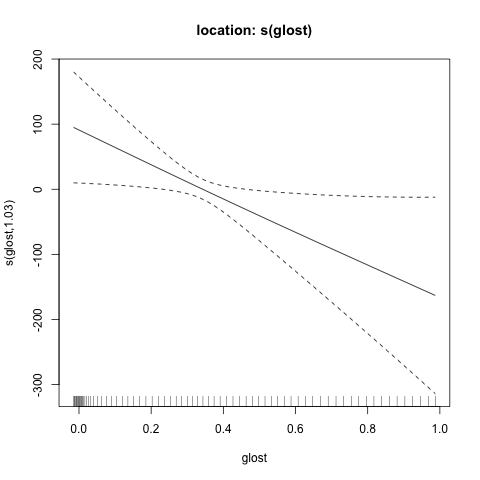

In [ ]:
bins=np.arange(0,3000,50)
%R fmla_gev <- list(AFI ~  s(glost,k=70) , ~ 1 , ~ 1) 
for ij in range(0,1):
  ilon=ptlon[ij]
  ilat=ptlat[ij]
  # Extract values for boxes
  dsij=ds.sel(lon=ilon,lat=ilat).load()
  df = dsij.to_dataframe()
  df = df.reset_index()
  # Remove zeros and NAN 
  # Remove timeseries with less than 15 data (as in Bilotta et al.)
  # Save rows removed
  dfsave=df[(df['AFI'] <= 0.)|(df['AFI'].isna())]
  df = df[df['AFI'] > 0.]

  dfsave=pd.concat([dfsave, df.groupby(['lon', 'lat']).filter(lambda x: len(x) <= 49)])
  df=df.groupby(['lon', 'lat']).filter(lambda x: len(x) > 49)
  # Convert xarray to pandas DataFrame to R data.frame
  # You can now work with 'r_df' in R

  r_df = ro.conversion.py2rpy(df)
  globalenv['r_df'] = r_df

  # EVGAM model fitting  
  %R m_gev <- evgam(fmla_gev, r_df, family = "gev")
  %R gev_pred <- predict(m_gev, r_df, type = "response")
  %R gev_rl100 <- predict(m_gev, r_df, prob = 0.99)
  print('#############')
  print('#############')
  print(f'Point {ij+1}')
  print('#############')
  print('#############')

  %R plot(m_gev)
  %R pp<-summary(m_gev)
  %R location_pvalue<-pp[[2]][['location']][['Pr(>|t|)']]
  %R xx<-pp[[2]][['location']]